# 01 Exploratory Data Analysis(EDA) and Preprocessing

Company Accounts publically available from Companies House https://download.companieshouse.gov.uk/Accounts_Monthly_Data-November2025.zip.  
298,461 Accounts.  
18.53GB uncompressed.  

This is a living document and has been updated after full itterations of the CRISP-DM cycle, taking into account learning at later stages such as reviewing errors from ML predictions


In [2]:
# Standard library
import random
import webbrowser
from pathlib import Path, PurePosixPath
from typing import Sequence
from zipfile import ZipFile

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import powerlaw
import seaborn as sns
from bs4 import BeautifulSoup
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import LabelEncoder, Normalizer

# Local
from ixbrl_ai.display import display_wide, heading
from ixbrl_ai.sample import DataSample

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Global definitions
MAX_WORDS = 15
SEED = 42
# High so that 1% subset has enough examples with cross validation 3
MIN_EXAMPLES = 350 

# Set random seed
np.random.seed(SEED)
random.seed(SEED)


# 1. HTML Accounts

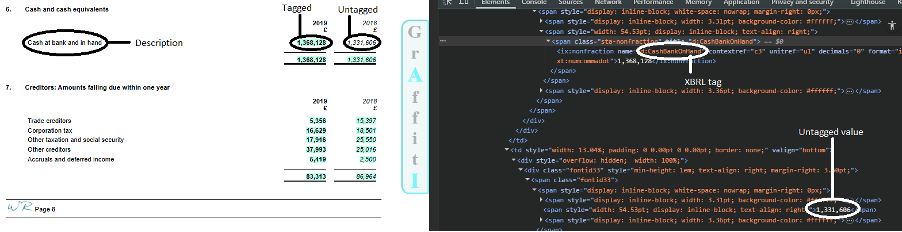.  
Figure 1 Example of iXBRL document, opened with Graffiti viewer(www.stechanalytics.com) with the underlying html shown on the right. Showing that XBRL tagged items are in an ix:nonfraction node, with a named element(xbrl concept), but untagged items are in standard html nodes such as span nodes.

It is easy to extract iXBRL tagged item and there are fixed taxonomies that clearly categorise what the value is. e.g. FRC taxonomies https://www.frc.org.uk/library/standards-codes-policy/accounting-and-reporting/frc-taxonomies/

It is possible to extract the untagged data.



In [4]:
def parse_html_file(file_path: Path) -> BeautifulSoup:
    """ Parses html file with BeautifulSoup

    Args:
        file_path (Path): Path to the file

    Returns:
        BeautifulSoup: BeautifulSoup object containing the parsed HTML content
    """
    
    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]
    html_content = None
    
    for encoding in encodings:
        try:
            with open(file=file_path, mode="r", encoding=encoding) as f:
                html_content = f.read()
            break
        except UnicodeDecodeError:
            continue
    
    if html_content is None:
        print(f"Warning: Could not read file {file_path}")
        return BeautifulSoup(markup="", features="html.parser")

    return BeautifulSoup(markup=html_content, features="html.parser")

## 1.1 Load Sample of html accounts

In [6]:
path_to_data= Path('~/Downloads/Accounts_Monthly_Data-November2025').expanduser()
files = [file for file in path_to_data.iterdir() if file.is_file()]

In [7]:
suffixes= [file.suffix for file in files]

zip_index = suffixes.index(".zip")

with ZipFile(files[zip_index]) as z:
    zip_suffixes = [PurePosixPath(name).suffix for name in z.namelist()]


set(suffixes + zip_suffixes)

{'', '.html', '.xhtml', '.zip'}

In [7]:
100 * np.sum(np.array(suffixes) == ".zip")/len(suffixes)

0.05157142139544229

The main files of interest are html and xhtml formats. While html and xhtml are very similar and most code should work across both it should be noted that sometimes they will behave differently(depending on language and packages).

- ESEF or UKSEF packages the files into a zip archive, but the underlying format inside them is xhtml. 
- Only 0.05% of the returns are in a zip, so these notebooks won't extract or use them. 

Others sources of data have different html/xhtml mixes


In [8]:
sample_size = 1000
no_tables_html= None
many_tables_html= None

document_htmls = [parse_html_file(file_path=file) for file in files[0:sample_size]]
tables = [len(document_html.find_all(name="table")) for document_html in document_htmls]
table_lengths = np.array(tables)

In [12]:
def view_html(files: Sequence[Path], index: int) -> None:
    """ Shows html in viewer(Positron) not sure if it work on other IDEs

    Args:
        index (int): index
    """
    path = files[index]
    webbrowser.open(url=path.as_uri())

## 1.2 HTML table nodes

In [ ]:
display(f"Docs with table nodes: {len(table_lengths) - np.sum(table_lengths == 0)} out of {len(table_lengths)}")
# First document with 11 tables
view_html(files=files, index=np.flatnonzero(table_lengths == 11)[0])

'Docs with table nodes: 847 out of 1000'

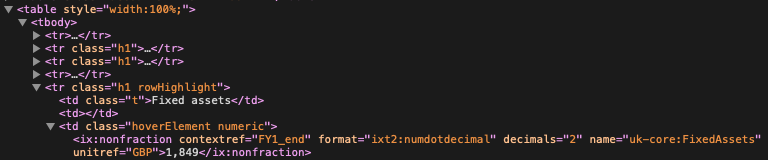

- Most accounts ~85% use html table nodes. 
- The relevant iXBRL data have their own node types such as ix:nonfraction, and can be parsed using Beautiful soup. 
- The description is in table and could also be extracted by parsing the table node. 


## 1.3 No table nodes

In [ ]:
display(f"Docs without any table nodes {np.sum(table_lengths == 0)} out of {len(table_lengths)}")
view_html(files=files, index=np.flatnonzero(table_lengths == 0)[4])

'Docs without any table nodes 153 out of 1000'


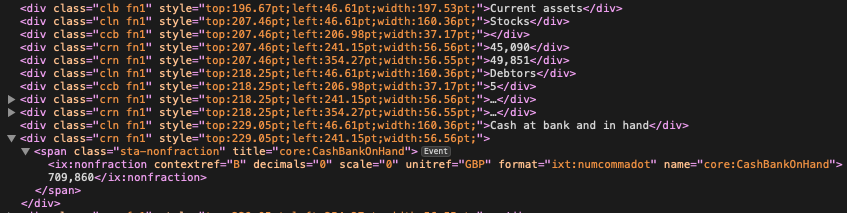

- Some accounts ~15% don't use html table nodes.
- The iXBRL data can be easily extracted, but untagged items like the descriptions and values can be hard to extract. 
- To extract this data you have to write bespoke code to recreate the tables based on the nodes' positions. 
- I have written R code that can also extract the tabula data from these documents that don't use table nodes. This code doesn't form part of these notebooks. 
- Since this is a minority group and there is a sufficiently large population, these notebooks won't extract data from these document. 


## 1.4 Structure of data and features

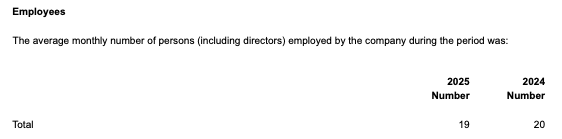

Here we have.   
Table name: Employees.   
Description: Total.    
Headings: "2025 Number" and "2024 Number".  

- Initial versions just extracted and used the descriptions for the ML. But here you can see that the description(Total) doesn't tell you enough information about what the value is, you also need the headings and table name.  
- The actual value wouldn't be a great feature since number and text can vary greatly for the same class, but detecting the type of value could be useful, e.g. is it monetary or text. 
- I have written R code internally which uses all three features and it improves ML.   
- These notebook just uses the description since it's the primary feature that is sufficient for most situations. The analysis and ML in these notebooks largerly follows over.  

# 2. EDA over extracted data
Data extracted from https://download.companieshouse.gov.uk/Accounts_Monthly_Data-November2025.zip.  
298,461 Accounts.  
Extracted using 00_ixbrl_data_extraction.ipynb.  


In [5]:
dataset_pl = (
    pl.read_parquet("data/table_extracted_df_v5.parquet")
    .rename({"label": "xbrl_concept"})
    )

## 2.1 Describe Dataset

In [11]:
def describe_dataset(dataset_pl: pl.DataFrame, description: str, label: str) -> dict:
    """ Describes the key characteristics of the dataset

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): The column name of the description feature
        label (str): The column name of the label

    Returns:
        dict: Key characteristics
    """
    description_col = dataset_pl[description]
    label_col = dataset_pl[label]
    word_count = description_col.str.count_matches(r"\w+").drop_nulls()
    word_mode = word_count.mode()
    word_mode_value = word_mode[0] if len(word_mode) > 0 else None

    stats = {
        "Shape": dataset_pl.shape,
        "Schema": dataset_pl.schema.items(),
        "Labels": label_col.n_unique(),
        "Unique descriptions": description_col.n_unique(),
        "Unique descriptions and labels": dataset_pl.select([description, label]).unique().height,  # n_unique doesn't give unique paris
        "Missing description values": description_col.null_count(),
        "Missing xbrl concepts": label_col.null_count(),
        "Mean description length(words)": word_count.mean(),
        "Mode description length(words)": word_mode_value,
        "Min description length(words)": word_count.min(),
        "Max description length(words)": word_count.max(),
        "Punctuation count(No words or letters)": description_col.str.contains(r"^[^\w\s]+$").fill_null(False).sum(),
    }
    heading("Descibe dataset")
    display(stats)
    return stats

description_stats = describe_dataset(dataset_pl, description="description", label="xbrl_concept")

## Descibe dataset

{'Shape': (2857703, 3),
 'Schema': odict_items([('table_index', Int64), ('description', String), ('xbrl_concept', String)]),
 'Labels': 956,
 'Unique descriptions': 266178,
 'Unique descriptions and labels': 282515,
 'Missing description values': 0,
 'Missing xbrl concepts': 0,
 'Mean description length(words)': 7.767105958876762,
 'Mode description length(words)': 2,
 'Min description length(words)': 0,
 'Max description length(words)': 1762,
 'Punctuation count(No words or letters)': 19814}

- The main columns of interest are both strings
    - The description is inerently text based, where NLP could be useful.
    - The xbrl_concepts is a nominal category, so we could encode that to numeric labels. But the actual text could be useful in some preliminary analysis.  
- 2,857,703 lines of data across 956 labels, should provide enough training data but that will depend on the distribution across the labels.
- There are no null or completely missing data, but there are some descriptions that have no words. So that will need cleaning.
- 19,814 have no letters and are just punctuation and other characters. These need to be removed completely.
- Max word length of 1762 suggests an issue with extraction, the descriptions should normally just be a few words and a sentence at max.
- You have 266,278 unique descriptions mapped to 956 labels, which means multiple descriptions would be mapped to each label.
- There are 282,515 unique description and labels, vs 266,178 unique descriptions suggesting that there might be some descriptions mapped to different labels. - I'll look into that in a bit more detail further down


## 2.2 Frequency rank plot

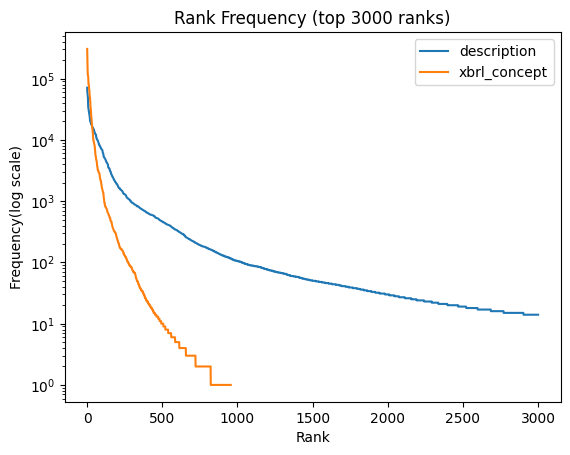

In [12]:
def frequency_rank_plot(
    dataset_pl: pl.DataFrame, description: str, label: str, max_rank: int = 3_000
) -> None:
    """Frequency rank plot

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): The column name of the description feature
        label (str): The column name of the label
        max_rank (int, optional): Cutoff number for how many tanks to show. Defaults to 3_000.
    """
    xbrl_concept_frequency = (
        dataset_pl.group_by(label)
        .len()
        .sort("len", descending=True)
        .get_column("len")
        .to_list()
    )
    description_frequency = (
        dataset_pl.group_by(description)
        .len()
        .sort("len", descending=True)
        .get_column("len")
        .to_list()
    )
    xbrl_concept_frequency = xbrl_concept_frequency[:max_rank]
    description_frequency = description_frequency[:max_rank]
    ax = sns.lineplot(
        y=description_frequency,
        x=np.arange(1, len(description_frequency) + 1),
        label=description,
    )
    sns.lineplot(
        y=xbrl_concept_frequency,
        x=np.arange(1, len(xbrl_concept_frequency) + 1),
        label=label,
        ax=ax,
    )
    ax.set_yscale("log")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Frequency(log scale)")
    ax.set_title(f"Rank Frequency (top {max_rank} ranks)")
    plt.show()


frequency_rank_plot(dataset_pl, description="description", label="xbrl_concept")

- Descriptions have a much longer tail
- The low ranked ixbrl concepts have a very high frequency of use.

## 2.3 Word count of discriptions distribution

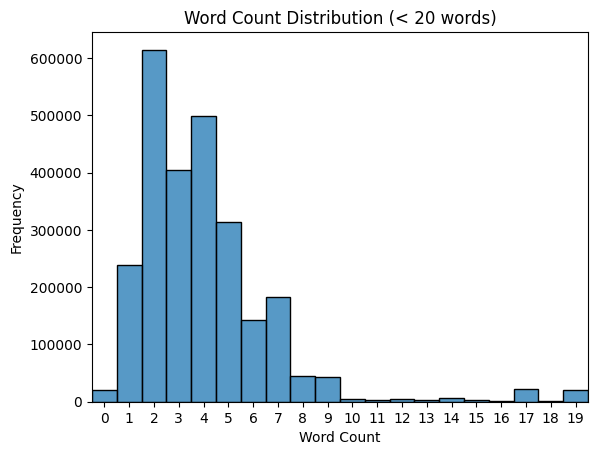

In [18]:
def plot_word_count(dataset_pl: pl.DataFrame, description: str) -> None:
    """Plots histogram of the word count

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name of the description feature
    """
    word_count = dataset_pl[description].str.count_matches(r"\w+").drop_nulls()
    short_word_count = word_count.filter(word_count < 20)

    ax = sns.histplot(short_word_count, binwidth=1, binrange=(-0.5, 19.5))
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.set_title("Word Count Distribution (< 20 words)")
    ax.set_xlim(-0.5, 19.5)
    ax.set_xticks(range(0, 20, 1))
    plt.show()


plot_word_count(dataset_pl, "description")

- Very rough bell shap, with a long tail on the right
- Most descriptions have a word count between 1-9, with a mode of 2.

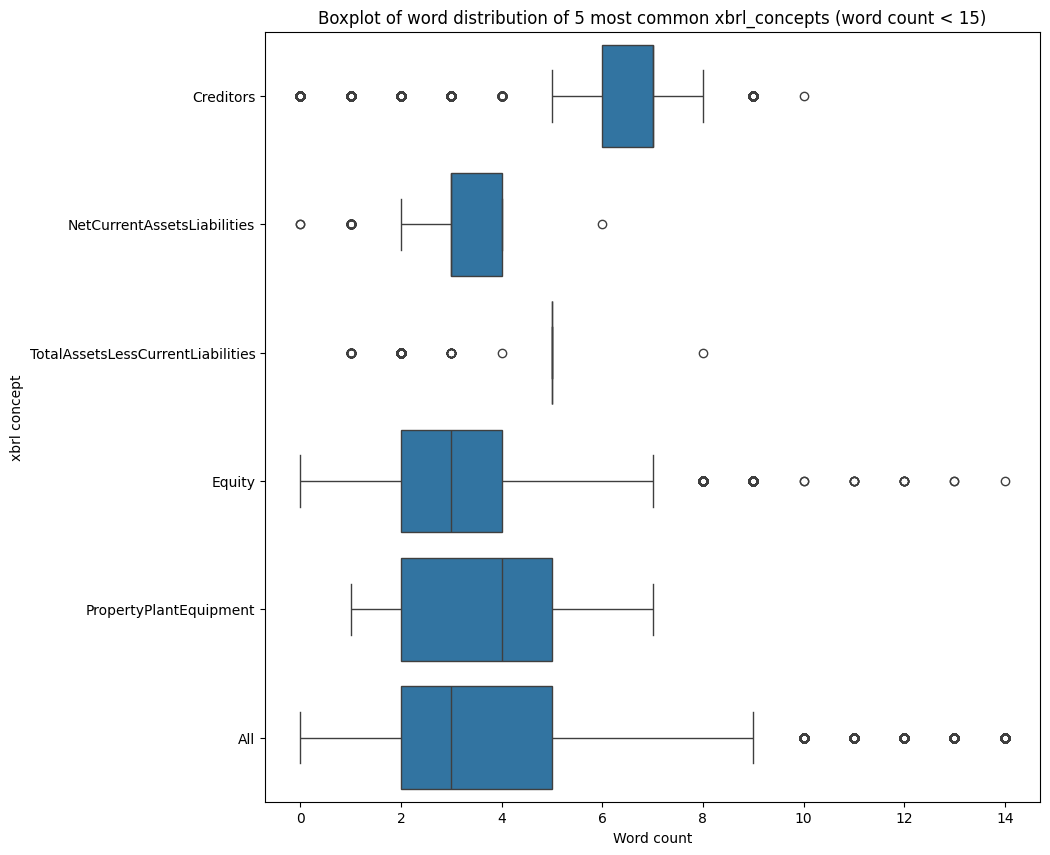

In [19]:
def plot_word_distributions(dataset_pl: pl.DataFrame, description: str, label: str) -> None:
    """Plots boxplot of the 5 most common labels along with boxplot of everything

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name of the description feature
        label (str): Column name of label
    """

    df = dataset_pl.with_columns(pl.col(description).str.count_matches(r"\w+").alias("word_count"))

    top_labels = df.group_by(label).len().sort("len", descending=True).head(5).get_column(label).to_list()

    all_df = df.select(pl.lit("All").alias(label), pl.col("word_count"))

    top_word_counts = (
        df.filter(pl.col(label).is_in(top_labels))
        .select(label, "word_count")
        .vstack(all_df)
        .filter(pl.col("word_count") < MAX_WORDS)
    )
    fig, ax1 = plt.subplots(figsize=(10, 10))
    sns.boxplot(y=label, x="word_count", data=top_word_counts.to_pandas(), ax=ax1)
    ax1.set_ylabel(label.replace("_", " "))
    ax1.set_xlabel("Word count")
    ax1.set_title(f"Boxplot of word distribution of 5 most common {label}s (word count < {MAX_WORDS})")

    plt.show()


plot_word_distributions(dataset_pl, description="description", label="xbrl_concept")

- Looking at the most 5 common xbrl concepts(label) used, they all have different distribution of the word count of their descriptions(feature).
- The interquartile ranges for them all are between two and seven. 

## 2.4 Samples of datasets

In [20]:
def display_filtered_data(dataset_pl: pl.DataFrame, description: str) -> None:
    """Displays samples of datasets with various characteristics,
    head, uniuqe, no word math, long word match and between 9 and 18 words

    Args:
        dataset_pl (pl.DataFrame): Dataset
        description (str): Column name for description feature
    """

    df = dataset_pl.with_columns(
        pl.col(description).str.count_matches(r"\w+").alias("wc"),
        pl.col(description).hash(seed=SEED).alias("hash"),
    )
    heading("Data extracts")

    heading("Sample")
    display_wide(dataset_pl.drop("table_index"))

    heading("Unique and common descriptions")

    display_wide(
        df.group_by(description)
        .agg(pl.len().alias("n"), pl.col("hash").first())
        .sort(["n", "hash"])
        .drop("hash")
    )

    heading("No word matches")
    no_words_pl = df.filter(pl.col("wc") == 0).sort("hash").drop(["table_index", "hash"])
    sample_n = min(20, no_words_pl.height)
    if no_words_pl.height > 0:
        display(no_words_pl.sample(n=sample_n, seed=SEED, with_replacement=False))
    else:
        display("Nothing with no words")

    heading("Over 100 words")
    long_words_pl = df.filter(pl.col("wc") > 100).sort("hash").drop("hash")
    sample_n = min(20, long_words_pl.height)
    if long_words_pl.height > 0:
        display(
            long_words_pl.get_column(description)
            .sample(n=sample_n, seed=SEED, with_replacement=False)
            .to_list()
        )
    else:
        display("Nothing with over 100 words")

    def display_descriptions_of_length(str_length: int):
        heading(f"Showing descriptions of length {str_length}")
        filtered_pl = (
            df.filter(pl.col("wc") == str_length).get_column(description).unique(maintain_order=True)
        )

        sample_n = min(20, filtered_pl.len())
        if filtered_pl.len() == 0:
            display(f"Noting with {str_length} words")
            return

        display(filtered_pl.sample(n=sample_n, seed=SEED, with_replacement=False).to_list())

    for i in range(9, 18):
        display_descriptions_of_length(i)


display_filtered_data(dataset_pl, "description")

## Data extracts

## Sample

description,xbrl_concept
str,str
"""29/11/2025""","""DateAccountantsReport"""
"""Debtors""","""Debtors"""
"""Cash at bank and in hand""","""CashBankOnHand"""
"""Creditors: Amounts Falling Due Within One Year""","""Creditors"""
"""NET CURRENT ASSETS (LIABILITIES)""","""NetCurrentAssetsLiabilities"""
"""TOTAL ASSETS LESS CURRENT LIABILITIES""","""TotalAssetsLessCurrentLiabilities"""
"""NET ASSETS""","""NetAssetsLiabilities"""
"""Income and Expenditure Account""","""Equity"""
"""R Tomlin Director""","""DirectorSigningFinancialStatements"""


## Unique and common descriptions

description,n
str,u32
"""JMF LIVE LIMITED""",1
"""34,414""",1
"""49,246""",1
"""120,175""",1
"""A Cox - Director""",1
"""Approved by order of the board of trustees on 22 November 2025 and signed on its behalf by:""",1
"""K Riley Director""",1
"""Mrs Kate Smith Director""",1
"""Eyal Landau""",1


...

['Interim dividend of £2.105  (2023 - £0.16) per each Ordinary Shares of £1 each',
 'Registered Number: 06029965\nCtrl-Ware Limited\n\nStatement of Financial Position\nAs at 31 December 2024',
 'D P + R Jones Developments Limited\n\nStatement of Financial Position\nAs at 28 February 2025',
 'J D Property Estates Services Limited\n\nStatement of Financial Position\nAs at 31 July 2025',
 'Registered Number: 13941224\nMONTYS DELI AND KITCHEN LTD\n\nBalance Sheet\nAs at 28 February 2025',
 'PJ Smith Roofing & Building Services Ltd.\n\nStatement of Financial Position\nAs at 30 April 2025',
 'The principal activity of the company during the year under review was trade of electricity.',
 'Registered Number: 05777761\nSTRUCTURAL REPAIRS LTD\n\nStatement of Financial Position\nAs at 30 April 2025',
 'Registered Number: 12529723\nMACBROOK CONSTRUCTION LTD\n\nStatement of Financial Position\nAs at 31 March 2025',
 'The principal activity of the company during the year under review was investment 

## Showing descriptions of length 16

['The principal activity of the company during the year under review was general cleaning of buildings.',
 'The total distribution of dividends for the year ended 31 August 2024 will be £ 784,000 .',
 'Registered Number: 11308144\nCYNOSURE IMPERIUM CONSULTING LTD\n\nStatement of Financial Position\nAs at 30 April 2025',
 'This report was approved by the board on 11 November 2025 and signed on its behalf.',
 'Registered Number: 15032921\nEVERY STORY PRODUCTIONS LIMITED\n\nStatement of Financial Position\nAs at 31 March 2025',
 'Director\n\nAqib Afzal\n\n\n\n\nRegistered Number\n\n14268642\n\n\n\nRegistered Office\n\n115 Oscott School Lane\n\nBirmingham\n\nB44 9EN\n\n\n\n1',
 'Registered Number: 11815078\nMEBHILL CLEANING SERVICES LIMITED\n\nStatement of Financial Position\nAs at 28 February 2025',
 'Caroline Webster FCA\n\n\n (Senior Statutory Auditor)\n\n\n for and on behalf of \n\n\nUHY Ross Brooke\n\n\n, Statutory Auditor',
 'Registered Number: 15521264\nJD APPARELS UK LTD\n\nStateme

## Showing descriptions of length 17

['The principal activity of the company during the year under review was the development of residential dwellings .',
 'The principal activity of the company during the year under review was supply of entertainment control systems.',
 'Director\n\nDeborah Mills\n\n\n\nRegistered Number\n\nSC748135\n\n\n\nRegistered Office\n\nFlat 3 24 Hesperus Crossway\n\nEdinburgh\n\nEH5 1RP\n\n\n\n1',
 'These accounts were approved by the members on 17 November 2025 and signed on their behalf by:',
 'These accounts were approved by the members on 17 September 2025 and signed on their behalf by:',
 'Director\n\nKennedy Mazendame\n\n\n\nRegistered Number\n\n12485595\n\n\n\nRegistered Office\n\n19 Walnut Close\n\nWeldon\n\nCorby\n\nNorthamptonshire\n\nNN17 3EE\n\n\n\n1',
 'Director\n\nAndrew Ntiamoah Adu-Baah\n\n\n\nRegistered Number\n\n13197649\n\n\n\nRegistered Office\n\n122b Croftdown Road\n\nLondon\n\nNW5 1HB\n\n\n\n1',
 'Diamond Investment Management Ltd\n\nThe principal activity of Diamond Investm

### Description
- Text feature.
- From these samples we can see there are various types of description, from nominal text, dates(temporal different formats), names(nominal) and figures(numeric ratio).
- The descriptions have all sorts of casing, sometimes everything is upper case, sometimes the first letter of each word is upper case. I'll need to standardise the casing(lowercase all).
- The rare descriptions are dates, names, and long extracts. 
- The most common descriptions "Called up share capital" is a standard phrase found on the blanace sheet. Many of the other common descriptions are also found on the balance sheet. This is because for smaller companies they don't need to include as "profit and loss" in their accounts but do need to submit a balance sheet. 
- When looking at descriptions that have no word many were "•", which contain no useful information and should be removed before they can be used in these notebooks. (This may need to be revisited if the heading and table name do contain enough information to categorise the item)
- Confirmed that the really long descriptions are errors with the extraction.
- At word length of 9 they are mainly correct descriptions extracted.  
- At 10 words or longer there are some extracts relating to dividends which are correct but most of it isn't the tabular data we are interested. It's extracting data like the principal activity, which is a text note rather than tabular data.
- Thee was a valid description at 15 words long
- At 16 words the sample didn't have any extracts that were of interest.


### XBRL Concept
- Categorical nominal label.  
- A single CammelCase word. 
- The subwords are an english description of the concept. 
- Similar wording often means that the concepts are more similar
- They are all standardised. 
- Only requires basic label encoding.  

## 2.5 Pareto plot

'Rank 95 percent 75'

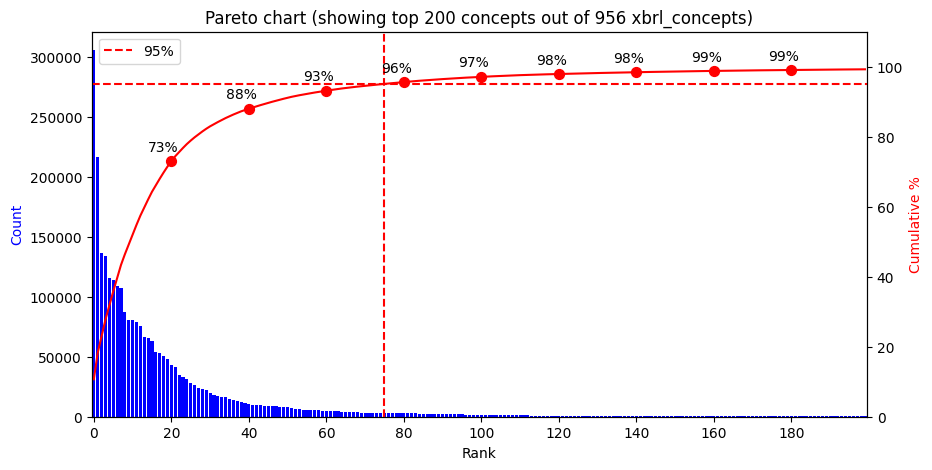

## Most commonly used concepts

,rank,xbrl_concept,len,percentage,log_count,cum_percentage
0,0,Equity,305780,0.107002,12.630624,0.107002
1,1,Creditors,216285,0.075685,12.284357,0.182687
2,2,NetCurrentAssetsLiabilities,136790,0.047867,11.826209,0.230554
3,3,TotalAssetsLessCurrentLiabilities,134347,0.047012,11.808189,0.277566
4,4,PropertyPlantEquipment,115373,0.040373,11.655934,0.317939
5,5,NetAssetsLiabilities,114078,0.039919,11.644646,0.357858
6,6,NameEntityOfficer,109103,0.038179,11.600057,0.396037
7,7,DateAuthorisationFinancialStatementsForIssue,106985,0.037437,11.580453,0.433474
8,8,CurrentAssets,87055,0.030463,11.374307,0.463938
9,9,AverageNumberEmployeesDuringPeriod,80792,0.028272,11.299646,0.492209


In [21]:
def plot_pareto(dataset_pl: pl.DataFrame, label: str, limit: int = 200) -> pd.DataFrame:
    """Plots a pareto over the different labels and table of those top labels

    Args:
        dataset_pl (pl.DataFrame): Dataset
        label (str): Column name of the label
        limit (int, optional): How many classes to show. Defaults to 200.

    Returns:
        pd.DataFrame: _description_
    """

    concept_balance_pl = (
        dataset_pl.group_by(label)
        .len()
        .sort("len", descending=True)
        .with_columns(
            (pl.col("len") / pl.col("len").sum()).alias("percentage"),
            (pl.col("len").log1p()).alias("log_count"),
        )
        .with_columns((pl.col("percentage").cum_sum()).alias("cum_percentage"))
        .with_row_index("rank")
    )

    concept_balance_df = concept_balance_pl.to_pandas()

    total = len(concept_balance_df)
    balance_limited_df = concept_balance_df.head(limit).reset_index(drop=True)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(np.arange(len(balance_limited_df)), balance_limited_df["len"].to_numpy(), color="blue")
    ax1.set_xlabel("Rank")
    step = max(1, limit // 10)
    xticks = np.arange(0, len(balance_limited_df), step)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks)
    ax1.set_ylabel("Count", color="blue")

    ax2 = ax1.twinx()
    ax2.plot(
        np.arange(len(balance_limited_df)), balance_limited_df["cum_percentage"].to_numpy() * 100, color="red"
    )
    ax2.set_ylabel("Cumulative %", color="red")
    ax1.set_title(f"Pareto chart (showing top {limit} concepts out of {total} {label}s)")

    ax2.scatter(xticks[1:], 100 * balance_limited_df["cum_percentage"].iloc[xticks[1:]], color="red", s=50)

    for r in xticks[1:]:
        y = balance_limited_df["cum_percentage"].iloc[r]
        ax2.text(r - 2, 100 * y + 2, f"{y:.0%}", ha="center", va="bottom")

    n = len(balance_limited_df)
    ax1.set_xlim(-0.5, n - 0.5)
    ax2.set_xlim(-0.5, n - 0.5)
    ax2.set_ylim(0, 110)

    rank_95_pct = concept_balance_pl.filter(pl.col("cum_percentage") > 0.95)[0, "rank"]

    ax2.axhline(95, linestyle="--", color="red")
    ax2.axvline(rank_95_pct, linestyle="--", color="red", label="95%")
    ax2.legend()

    display(f"Rank 95 percent {rank_95_pct}")
    plt.show()
    heading("Most commonly used concepts")
    display(concept_balance_df.head(20))

    return concept_balance_df


concept_balance_df = plot_pareto(dataset_pl, label="xbrl_concept")

This shows that there are a few XBRL concepts that are used very frequently with the top 75 concepts covering 95% of the items. 

## 2.6 Powerlaw, Exponential, Lognormal

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 329/329 [00:00<00:00, 2509.73it/s]

Alpha: 1.4139169932668763, xmin: 83.0


## Powerlaw vs lognormal. R<0 makes it closer to lognormal

R: -6.124214033559234, and p: 0.02013677004441069


## Powerlaw vs exponential. R>0 makes it closer to powerlaw

R: 430.54398153335296, and p: 1.02048606330697e-23


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


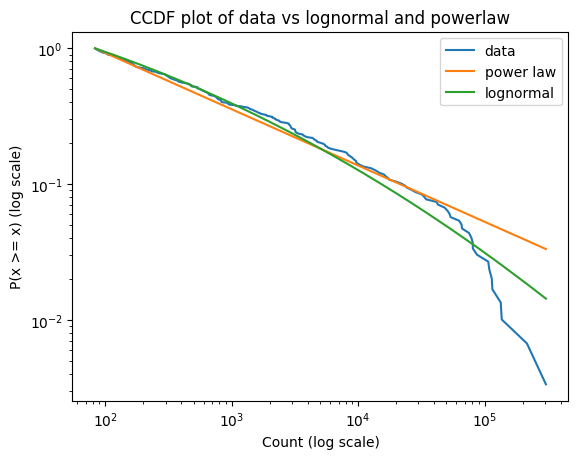

In [22]:
def powerlaw_analysis(concept_balance_df: pd.DataFrame) -> None:
    """Does a powerlaw analysis comparing with powerlaw, lognormal and exponential

    Args:
        concept_balance_df (pd.DataFrame): Concepts with counts
    """
    counts = concept_balance_df["len"].values
    fit = powerlaw.Fit(counts, discrete = True)
    print(f"Alpha: {fit.alpha}, xmin: {fit.xmin}")

    # Closer to lognormal
    heading("Powerlaw vs lognormal. R<0 makes it closer to lognormal")
    R, p = fit.distribution_compare("power_law", "lognormal")
    print(f"R: {R}, and p: {p}")

    # Closer to powerlaw
    heading("Powerlaw vs exponential. R>0 makes it closer to powerlaw")
    R, p = fit.distribution_compare("power_law", "exponential")
    print(f"R: {R}, and p: {p}")

    # CCDF plot is the probability of observing values at least as large as x
    ax = fit.plot_ccdf(label = "data")
    fit.power_law.plot_ccdf(label = "power law")
    fit.lognormal.plot_ccdf(label = "lognormal")
    ax.legend()
    ax.set_xlabel("Count (log scale)")
    ax.set_ylabel("P(x >= x) (log scale)")
    ax.set_title("CCDF plot of data vs lognormal and powerlaw")
    plt.show()

powerlaw_analysis(concept_balance_df)

- There isn't an exact match but the tests and graphing makes it look closer to lognormal than powerlaw or exponential.
- There is a very long tail
- This suggets that usage is through lots of different independent factors, there is no unconstrained growth just because a concept is "popular"

## 2.7 Multiple XBRL Concepts per Description

In [23]:
def multi_mapping(dataset_pl: pl.DataFrame, key: str, value: str) -> pl.DataFrame:
    """Shows mapping keys to unique values

    Args:
        dataset_pl (pl.DataFrame): Dataset
        key (str): The column to be the source of mapping
        value (str): The column which would be mapped to

    Returns:
        pl.DataFrame: Shows number of unique values per key, and structure the data so that mapping of key to value is shown
    """
    all_labels_pl = (
        dataset_pl.select(key, value)
        .unique()
        .sort(key)
        .with_columns(
            pl.col(value).count().over(key).alias("n_values"),
            pl.col(value).cum_count().over(key).alias("n"),
        )
        .filter(pl.col("n_values") > 1)
        .sort("n_values", descending=True)
        .with_row_index()
    )
    return all_labels_pl


def multi_label_analysis(all_labels_pl: pl.DataFrame, key: str, value: str, rows: int = 10) -> None:
    """Pivots the data wider to have all the different values on the same row

    Args:
        all_labels_pl (pl.DataFrame): Long table of keys mapped to values
        key (str): The column to be the source of mapping
        value (str): The column which would be mapped to
        rows (int, optional): How many rows to print. Defaults to 10.
    """

    heading(f"Multiple {value} per {key}")
    display_wide(all_labels_pl.pivot(values=value, on="n", index=[key, "n_values"]).head(rows))


all_labels_pl = multi_mapping(dataset_pl, "description", "xbrl_concept").with_columns(
    pl.col("xbrl_concept").str.replace_all("([a-z])([A-Z])", "$1 $2")
)
multi_label_analysis(all_labels_pl, key="description", value="xbrl_concept")

## Multiple xbrl_concept per description

description,n_values,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
str,u32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""4.""",41,"""Investments In Group Undertakings""","""Creditors""","""Other Creditors""","""Loans To Group Undertakings""","""Loans To Associates Joint Ventures Participating Interests""","""Additions Other Than Through Business Combinations Intangible Assets""","""Trade Creditors Trade Payables""","""Prepayments Accrued Income""","""Additions Other Than Through Business Combinations Property Plant Equipment""","""Investments In Associates Joint Ventures Participating Interests""","""Called Up Share Capital Not Paid""","""Prepayments""","""Accrued Income""","""Number Shares Authorised""","""Average Number Employees During Period""","""Name Controlling Party""","""Trade Debtors Trade Receivables""","""Value-added Tax Payable""","""Property Plant Equipment Gross Cost""","""Interest Similar Income Receivable""","""Accrued Liabilities""","""Administration Support Average Number Employees""","""Other Investments Other Than Loans""","""Intangible Assets Gross Cost""","""Finished Goods""","""Bank Overdrafts""","""Name Parent Entity""","""Accumulated Depreciation Impairment Property Plant Equipment""","""Amounts Owed By Group Undertakings Participating Interests""","""Other Debtors""","""Work In Progress""","""Dividend Declared Payable""","""Other Taxation Social Security Payable""","""Amounts Owed To Group Undertakings Participating Interests""","""Corporation Tax Payable""","""Accrued Liabilities Deferred Income""","""Debtors""","""Number Shares Allotted""","""Bank Borrowings Overdrafts""","""Other Interest Receivable Similar Income Finance Income""","""Raw Materials Consumables"""
"""3.""",40,"""Intangible Assets Gross Cost""","""Loans To Associates Joint Ventures Participating Interests""","""Investments In Group Undertakings""","""Administration Support Average Number Employees""","""Wages Salaries""","""Factored Debts Outstanding""","""Employee Benefits Free-text Comment""","""Other Debtors""","""Other Employee Expense""","""Average Number Employees During Period""","""Finished Goods""","""Accrued Liabilities""","""Number Shares Allotted""","""Selling Average Number Employees""","""Property Plant Equipment Gross Cost""","""Prepayments Accrued Income""","""Additions Other Than Through Business Combinations Intangible Assets""","""Called Up Share Capital Not Paid""","""Value-added Tax Payable""","""Dividend Declared Payable""","""Corporation Tax Payable""","""Additions Other Than Through Business Combinations Property Plant Equipment""","""Number Shares Authorised""","""Name Controlling Party""","""Trade Creditors Trade Payables""","""Loans To Group Undertakings""","""Other Investments Other Than Loans""","""Amounts Owed By Associates Joint Ventures Participating Interests""","""Accrued Liabilities Deferred Income""","""Trade Debtors Trade Receivables""","""Amounts Owed By Group Undertakings Participating Interests""","""Bank Borrowings Overdrafts""","""Increase From Depreciation Charge For Year Property Plant Equipment""","""Other Taxation Social Security Payable""","""Pension Costs Defined Contribution Plan""","""Debtors""","""Raw Materials Consumables""","""Other Creditors""","""Prepayments""","""Creditors""",null
"""5.""",34,"""Other Debtors""","""Amounts Owed To Associates Joint Ventures Participating Interests""","""Name Controlling Party""","""Creditors""","""Called Up Share Capital Not Paid""","""Amounts Owed By Associates Joint Ventures Participating Interests""","""Value-added Tax Payable""","""Corporation Tax Payable""","""Other Creditors""","""Work In Progress""","""Interest Payable Similar Charges Finance Costs""","""Trade Creditors Trade Payables""","""Other Taxation Social Security Payable""","""Other Investments 

- Most descriptions that have multiple XBRL concepts are numbers, names or generic descriptions like total or addition
- Some of the XBRL concepts look like they are similar to each other and others are very different

### 2.7.1 Similarity of XBRL Concepts

With the concept split up into words we can look at the cosine similarity of these concepts

In [24]:
def show_overlap_similarity(
    all_labels_pl: pl.DataFrame, key: str, value: str, rows: int = 100, levels: Sequence[int] = [0, 5, 10]
) -> pl.DataFrame:
    """Calculates cosin for each group

    Args:
        all_labels_pl (pl.DataFrame): Dataset with mapping
        key (str): Column name for group
        value (str): Column name for mapped values
        rows (int, optional): Number of rows to print. Defaults to 100.
        levels (Sequence[int], optional): The min number of values to display. Defaults to [0, 5, 10].

    Returns:
        pl.DataFrame: _description_
    """

    def fast_group_similarity(group_pl: pl.DataFrame) -> pl.DataFrame:
        """Just calculate the cosine for group

        Args:
            group_pl (pl.DataFrame): Just the group

        Returns:
            pl.DataFrame: Contains individual and over group similarity
        """

        vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 1), use_idf=False, norm="l2")

        labels_vectorized = vectorizer.fit_transform(group_pl[value])

        sim_pl = labels_vectorized @ labels_vectorized.T
        row_sum = np.asarray(sim_pl.sum(axis=1)).ravel()

        indiv_group_sim = (row_sum - 1) / (row_sum.size - 1)
        group_sim = indiv_group_sim.sum() / (row_sum.size)

        return group_pl.with_columns(
            pl.Series("indiv_group_sim", np.round(indiv_group_sim, 4)),
            pl.lit(np.round(group_sim, 4)).alias("group_sim"),
        )

    sim_pl = (
        all_labels_pl.group_by(key, maintain_order=True)
        .map_groups(fast_group_similarity)
        .sort("group_sim", descending=True)
    )

    with pl.Config(tbl_rows=rows, tbl_width_chars=1_000, fmt_str_lengths=1_000):
        for n in levels:
            display(sim_pl.filter(pl.col("n_values") > n))

    return sim_pl


sim_pl = show_overlap_similarity(all_labels_pl, key="description", value="xbrl_concept")


index,description,xbrl_concept,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
26033,"""Net (decrease)/increase in cash and cash equivalents""","""Increase Decrease In Cash Cash Equivalents After Foreign Exchange Differences Changes In Consolidation""",2,1,0.9412,0.9412
26034,"""Net (decrease)/increase in cash and cash equivalents""","""Increase Decrease In Cash Cash Equivalents Before Foreign Exchange Differences Changes In Consolidation""",2,2,0.9412,0.9412
26041,"""Net increase in cash and cash equivalents""","""Increase Decrease In Cash Cash Equivalents After Foreign Exchange Differences Changes In Consolidation""",2,1,0.9412,0.9412
26042,"""Net increase in cash and cash equivalents""","""Increase Decrease In Cash Cash Equivalents Before Foreign Exchange Differences Changes In Consolidation""",2,2,0.9412,0.9412
23813,"""Advanced""","""Increase In Loans Owed By Related Parties Due To Loans Advanced""",2,1,0.9309,0.9309
23814,"""Advanced""","""Increase In Loans Owed To Related Parties Due To Loans Advanced""",2,2,0.9309,0.9309
26395,"""Repaid""","""Decrease In Loans Owed To Related Parties Due To Loans Repaid""",2,1,0.9309,0.9309
26396,"""Repaid""","""Decrease In Loans Owed By Related Parties Due To Loans Repaid""",2,2,0.9309,0.9309
25191,"""Interest transactions""","""Increase Decrease In Loans Owed By Related Parties Attributable To Interest Transactions""",2,1,0.9258,0.9258


index,description,xbrl_concept,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
3235,"""Land and buildings""","""Accumulated Depreciation Impairment Property Plant Equipment""",6,1,0.5979,0.5988
3236,"""Land and buildings""","""Property Plant Equipment Gross Cost""",6,2,0.5768,0.5988
3237,"""Land and buildings""","""Description Depreciation Method For Property Plant Equipment""",6,3,0.5912,0.5988
3238,"""Land and buildings""","""Useful Life Property Plant Equipment Years""",6,4,0.5361,0.5988
3239,"""Land and buildings""","""Property Plant Equipment""",6,5,0.6996,0.5988
3240,"""Land and buildings""","""Depreciation Rate Used For Property Plant Equipment""",6,6,0.5912,0.5988
2573,"""Fixtures and fittings""","""Property Plant Equipment Gross Cost""",7,1,0.5481,0.578
2574,"""Fixtures and fittings""","""Accumulated Depreciation Impairment Property Plant Equipment""",7,2,0.5803,0.578
2575,"""Fixtures and fittings""","""Property Plant Equipment""",7,3,0.6701,0.578


index,description,xbrl_concept,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
1182,"""Transfers""","""Increase Decrease Due To Transfers Into Or Out Intangible Assets""",13,1,0.368,0.2746
1183,"""Transfers""","""Increase Decrease Due To Transfers Between Classes Property Plant Equipment""",13,2,0.3639,0.2746
1184,"""Transfers""","""Other Investments Other Than Loans""",13,3,0.0497,0.2746
1185,"""Transfers""","""Increase Decrease Due To Transfers Into Or Out Property Plant Equipment""",13,4,0.3926,0.2746
1186,"""Transfers""","""Transfers Into Or Out Property Plant Equipment Increase Decrease In Depreciation Impairment""",13,5,0.41,0.2746
1187,"""Transfers""","""Increase Decrease Due To Transfers Between Classes Intangible Assets""",13,6,0.3377,0.2746
1188,"""Transfers""","""Investments""",13,7,0.0796,0.2746
1189,"""Transfers""","""Transfers To From Property Plant Equipment Fair Value Model""",13,8,0.1827,0.2746
1190,"""Transfers""","""Further Item Increase Decrease In Depreciation Impairment PPEComponent Corresponding Total""",13,9,0.2283,0.2746


- While the labels are a single Cammel case word, they are made up from base words and can be split on each capital letter
- When split into words, they were count vectorised and then cosine similarity used to compare how similar the different concepts are for each group of descriptions.
- Some descriptions like "Taxation and social security costs" were used for very similar XBRL concepts like	"Other Taxation Social Security Payable" and "Taxation Social Security Payable", showing high group similarity. Maybe extracting more features like table name and heading would help differentiate them. Or maybe grouping similar XBRL concept together would be useful. 
- Other descriptions like numbers or dates were used for a wide variety of XBRL concepts with low group similarity.
- Generic descriptions like "Total" were also used for a variety of XBRL concepts and had low group similarity. This also suggets that extracting other features like table names and headings would be useful.

	

## 2.8 Multiple Descriptions per XBRL Concept

In [25]:
multi_labels_pl = multi_mapping(dataset_pl, "xbrl_concept", "description")

multi_label_analysis(multi_labels_pl, "xbrl_concept", "description")

## Multiple description per xbrl_concept

xbrl_concept,n_values,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,76807,76808,76809,76810,76811,76812,76813,76814,76815,76816,76817,76818,76819,76820,76821,76822,76823,76824,76825,76826,76827,76828,76829,76830,76831,76832,76833,76834,76835,76836,76837,76838,76839,76840,76841,76842,76843
str,u32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""NameEntityOfficer""",76843,"""Mr M P Dressen - Director""",""".........................................Mr Ben Simon WakefieldDirector""","""O Zhardan - Director""","""P A J Kerr - Director""","""A R Fiddy - Director""","""Tina GRIMES""","""MAKAM, Venkata Satya Bharath GuptaDirectorRegistered Company No. 12464439""","""Dary Sweeney""","""R I Hirst - Director""",""".........................................I TharumakunarajahDirector""","""EDGERTON, Heather AnnabelleDirector""","""Mr M Thompson""","""D Higgott - Director""","""Mrs N Wain - Director""","""B Bartlett - appointed 3 May 2024""","""Mr J C Sim - Director""","""Ms K K Pahal - Director""","""Mrs Amy Barker""","""J E Meek - Director""","""M J Revell Director""","""D Ropner - Director""","""Mrs A Gudgeon - Director""","""Mrs A L Hyde - Director""","""Ms C J Sims - Director""","""PIJANOWSKI, PiotrDirectorRegistered Company No. SC693451""","""Rebecca Suttill""","""Mr R C Grafton - Director""","""Mrs T A Wishart - Director""","""F Bayar - Director""","""D Lloyd FCCA - Director""","""A. Wilkinson - Director""","""Miss F H Rodda - Director""","""I T Russell - Director""","""Sharon Cecilia CroftsDirectorRegistered Company No. 04633828""","""P Hawkey - Director""",…,""".........................................Mr Jonathan BibbyDirector""","""G S I Irvine - Director""","""T Chaudhry""","""Mr R E Beggerow - Director""","""O T Brockley - Director""","""D MacLoughlin - Director""","""J Harrison Treasurer""","""W J S H Ullyott - Director""","""Mrs J A Newberry - Director""","""Mr R L Denham - Director""","""O A Sijuade - Director""","""CARREIRA, H A TDirectorRegistered Company No. 13977696""","""P Thompson - Director""","""RUSSELL, Andrew StuartDirector""","""T P Holdsworth - Director""","""Ali Ozyasin - Director""",""".........................................Mr Christian HeftiDirector""","""Mr I D White - Director""","""Mr I Ali""","""M J Leadbetter - resigned 28 February 2025""","""Darren McCroft Director""","""G D L Morgan - Director""","""C Silcox - Director""","""NAEEM, FarrahDirectorRegistered Company No. 07017200""","""Mr S Docherty""","""Mr J F Cobb - Director""","""N Stinchcombe - Director""","""R Crook - Director""","""W G Sleeman - Director""","""A A Sexton - Director""","""Mr Paul Robert Aidan Doyle""","""Mrs S L Jenkins - Director""","""Peter John Andrew GERRING""","""T D Tocher - Director""","""Ms C A Smith - Director""","""Mr I T Hunter - Director""","""Mrs D J Lowe - Director"""
"""DirectorSigningFinancialStatements""",38725,"""Mr Craig Young Director""","""Miss Robyn Marshman Director""","""Mr Nicolae Haramuz Director""","""Mr Ilmi Alija Director""","""Mrs Gabriella Palla Director""","""Andrew Moore""","""Mr Edward Grantham Director""","""Mr Scott Poulter Designated Member""","""Executor of the late David Anderson Director""","""Mr Ian Stevens Director""","""Miss Ramida Vijitphan Director""","""Mr Gagan Dugal Director""","""Jack Hook""","""Mrs Maria Pennington Director""","""Mr Robert Staples Director""","""Mr J Goodwin Director""","""Mr Kashif Akram Akram Director""","""Mr Pratheepraj Wijayanathan Director""","""Mr Thomas Bladen Director""","""Miss Haleema Farid Director""","""Mr Manwar Hussain Director""","""Mr Rezaul Hoque Director""","""Dr Mohammed Akuji Director""","""Mr Stephen Murray Director""","""Mr Bjorn Herbst Director""","""Mr 

- XBRL concepts like NameEntityOfficer, have a lot of descriptions, since there are a lot of unique names
- XBRL concepts like DescriptionPrincipalActivities and AddressLine1 have the varied descriptions, which makes sense. But this isn't the kind of tabular kind of data we are interested in. Software often puts plain text inside html tables and that's what's being extracted.  
- Some concepts have very similar descriptions, "short-term deposits" and "short term deposits". 
    - Maybe it would be good to remove some of puctuations symbols. But it might need to be bespoke and tested. Initial testing showed that removing some pictuation actually reduced the performance of the model.
    - Synonym mapping might be anther approach, it reduces noise making it easier for models to perform better. This function could actually be used as the basis to map common descriptions.



In [26]:
dataset_pl.filter(pl.col("xbrl_concept").str.contains("Address")).select("xbrl_concept").unique()

xbrl_concept
str
"""AddressLine2"""
"""AddressEntityBankers"""
"""AddressEntityCharityAuditors"""
"""AddressLine3"""
"""AddressLine1"""


- Should remove all these address rows. 

### 2.8.1 Similarity of descriptions per concept

In [27]:
show_overlap_similarity(multi_labels_pl, "xbrl_concept", "description")


index,xbrl_concept,description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
281985,"""AuditAccountancyCosts""","""Accountancy fees""",2,1,1.0,1.0
281986,"""AuditAccountancyCosts""","""Accountancy Fees""",2,2,1.0,1.0
281989,"""BankCharges""","""Bank Charges""",2,1,1.0,1.0
281990,"""BankCharges""","""Bank charges""",2,2,1.0,1.0
282035,"""EquityLiabilities""","""Total equity and liabilities""",2,1,1.0,1.0
282036,"""EquityLiabilities""","""TOTAL EQUITY AND LIABILITIES""",2,2,1.0,1.0
282155,"""OtherOperatingIncome""","""Other operating income""",2,1,1.0,1.0
282156,"""OtherOperatingIncome""","""Other operating income:""",2,2,1.0,1.0
282201,"""Short-termDepositsClassifiedAsCashEquivalents""","""Short term deposits""",2,1,1.0,1.0


index,xbrl_concept,description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
262634,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 29 November 2024 in accordance with Section 476 of the Companies Act 2006.""",493,1,0.9259,0.9261
262635,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 31 May 2025 in accordance with Section 476 of the Companies Act 2006""",493,2,0.9377,0.9261
262636,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 8 October 2024 in accordance with Section 476 of the Companies Act 2006.""",493,3,0.9346,0.9261
262637,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 31st July 2024 in accordance with Section 476 of the Companies Act 2006.""",493,4,0.9289,0.9261
262638,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 5 March 2025 in accordance with Section 476 of the Companies Act 2006.""",493,5,0.9462,0.9261
262639,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 26 November 2024 in accordance with Section 476 of the Companies Act 2006.""",493,6,0.9281,0.9261
262640,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 31 August 2025 in accordance with Section 476 of the Companies Act 2006""",493,7,0.9348,0.9261
262641,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 23 October 2024 in accordance with Section 476 of the Companies Act 2006.""",493,8,0.928,0.9261
262642,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 29th March 2025 in accordance with Section 476 of the Companies Act 2006.""",493,9,0.9363,0.9261


index,xbrl_concept,description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
262634,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 29 November 2024 in accordance with Section 476 of the Companies Act 2006.""",493,1,0.9259,0.9261
262635,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 31 May 2025 in accordance with Section 476 of the Companies Act 2006""",493,2,0.9377,0.9261
262636,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 8 October 2024 in accordance with Section 476 of the Companies Act 2006.""",493,3,0.9346,0.9261
262637,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 31st July 2024 in accordance with Section 476 of the Companies Act 2006.""",493,4,0.9289,0.9261
262638,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 5 March 2025 in accordance with Section 476 of the Companies Act 2006.""",493,5,0.9462,0.9261
262639,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 26 November 2024 in accordance with Section 476 of the Companies Act 2006.""",493,6,0.9281,0.9261
262640,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the period ended 31 August 2025 in accordance with Section 476 of the Companies Act 2006""",493,7,0.9348,0.9261
262641,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 23 October 2024 in accordance with Section 476 of the Companies Act 2006.""",493,8,0.928,0.9261
262642,"""StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit""","""The members have not required the company to obtain an audit of its financial statements for the year ended 29th March 2025 in accordance with Section 476 of the Companies Act 2006.""",493,9,0.9363,0.9261


index,xbrl_concept,description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
281985,"""AuditAccountancyCosts""","""Accountancy fees""",2,1,1.0,1.0
281986,"""AuditAccountancyCosts""","""Accountancy Fees""",2,2,1.0,1.0
281989,"""BankCharges""","""Bank Charges""",2,1,1.0,1.0
281990,"""BankCharges""","""Bank charges""",2,2,1.0,1.0
282035,"""EquityLiabilities""","""Total equity and liabilities""",2,1,1.0,1.0
…,…,…,…,…,…,…
280742,"""NumberSharesAuthorised""","""4.""",9,7,-0.125,-0.1111
280743,"""NumberSharesAuthorised""","""9.""",9,8,-0.125,-0.1111
280744,"""NumberSharesAuthorised""","""2.""",9,9,-0.125,-0.1111


- XBRL concepts like StatementThatMembersHaveNotRequiredCompanyToObtainAnAudit, have lots of similar descriptions and have high group similarity. They are standardised statements with the differences mainly being dates.
- XBRL concepts like CurrentAssets have numbers as their description which are all different showing low group similarity. This suggests a possible issue with extraction, the description should be text and the values are numberic. I wouldn't expect the description to be numberic.
- XBRL concepts like NameEntityOfficer have lots of different names, hence the low group similarity.
- XBRL concept like CostsRaisingFunds had varied descriptions like "Total Expenditure", "Raising funds", "Investment management costs"	showing low similarity.

# 3 Canonicalization and label engineering
- Basic text cleaning
- Replace specific date 1982-03-31 which has tax meaning with canconical token
- Replace names, companies, numbers, dates and post codes with canoncial tokens based on actual value and XBRL concept
- Label engineering, if the feature is just a name, company, number or date then replace the label with a canonical label. It's not possible for those features to meaninfully predict the actual label but knowing the feature type could be useful as a label

In [7]:
def clean_field(dataset_pl: pl.DataFrame, feature: str, output_feature: str) -> pl.DataFrame:
    """Cleans the field

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature to clean
        output_feature (str): Column name for the cleaned feature

    Returns:
        pl.DataFrame: Dataset including the cleaned feature
    """

    clean = (
        pl.col(feature)
        .str.to_lowercase()
        .str.strip_chars()
        .str.replace_all(r"\(|\)", "")
        .str.replace_all(r":", " ")
        .str.replace_all(r"\s+", " ")
        # .str.replace_all(r'\/', ' ') # this actually reduces performance
        .str.strip_chars()
    )

    return dataset_pl.with_columns(clean.alias(output_feature))


def canonicalize_field(dataset_pl: pl.DataFrame, feature: str, output_feature: str) -> pl.DataFrame:
    """Normalize has multiple meanings so use canonicalize
    Replace names, dates and numbers with standardised hubble_type value

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of the feature
        output_feature (str): Column name for the canonical feature

    Returns:
        pl.DataFrame: Dataset including canonical feature
    """

    company_pattern = r".*(ltd|limited|plc|(public limited company)|(public limited)|llp|(limited liability partnership)|lp|(limited partnership)|co)\b"
    postcode_pattern = r"(?i)\b(?:GIR 0AA|(?:[A-Z]{1,2}\d[A-Z\d]?|\d[A-Z]{2})\s?\d[A-Z]{2})\b"
    date_pattern = r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d{1,2}\w{0,2} \b(?:jan(?:uary)?|feb(?:ruary)?|mar(?:ch)?|apr(?:il)?|may|jun(?:e)?|jul(?:y)?|aug(?:ust)?|sep(?:t(?:ember)?)?|oct(?:ober)?|nov(?:ember)?|dec(?:ember)?)\b\s*\d{0,4}"

    canonicalize = (
        pl.col(feature)
        .str.replace(
            r"31.*(march|03).*1982", "hubble_date_1982_03_31"
        )  # Special date for tax so treat differently
        .str.replace_all(company_pattern, "hubble_company_name")
        .str.replace(postcode_pattern, "hubble_postcode")
        .str.replace_all(date_pattern, "hubble_date")
        .str.replace_all(r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d+\w* \w+ \d{2,4}", "hubble_date")
        .str.replace_all(r"(?:as\s+)?(?:(at|on|in|as)\s+)?\d+[\s\/\-]\d+[\s\/\-]\d+", "hubble_date")
        .str.replace_all(r"[\d,\.]+(rd|st|nd|th|)", "hubble_number")
        .str.replace_all(r"(.* |^)(mr|ms).*", "hubble_name")
        .str.strip_chars()
    )

    return dataset_pl.with_columns(canonicalize.alias(output_feature))


def standardise_names(dataset_pl: pl.DataFrame, feature: str, label: str) -> pl.DataFrame:
    """Backup to ensure all names are replaced with hubble_name

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature
        label (str): Column name of label

    Returns:
        pl.DataFrame: Dataset with standardised names
    """

    names = [
        "NameEntityOfficer",
        "NamedEntityOfficer",
        "NameDirector",
        "DirectorSigningFinancialStatements",
        "NameSeniorStatutoryAuditor",
        "NameOfEngagementPartner",
        "NameLLPMember",
        "NameTrustee",
        "NameGeneralPartner",
        "NameLimitedPartner",
        "NameAssociate",
        "NameAccountantResponsible",
    ]
    company_names = [
        "NameEntity",
        "EntityCurrentLegalOrRegisteredName",
        "NameEntityLawyersOrLegalAdvisersEntityTradingName",
        "NameOfReportingEntity",
        "NameAuditor",
        "NameSeniorStatutoryCharityAuditor",
        "NameEntityCharityAuditors",
        "NameIndividualAuditor",
        "NameEntityAuditors",
        "NameOfAuditFirm",
        "NameSubsidiary",
        "NameParent",
        "NameImmediateParent",
        "NameUltimateParent",
        "NameRelatedParty",
        "NameEntityAccountants",
        "NameControllingParty",
        "NameEntityBankers",
        "NameParentEntity",
        "NameOrDescriptionRelatedPartyIfNotDefinedByAnotherTag",
    ]

    return dataset_pl.with_columns(
        pl.when(pl.col(label).is_in(names))
        .then(pl.lit("hubble_name"))
        .when(pl.col(label).is_in(company_names))
        .then(pl.lit("hubble_company_name"))
        .otherwise(pl.col(feature))
        .alias(feature)
    )


def target_engineer(dataset_pl: pl.DataFrame, feature: str, label: str, output_label: str) -> pl.DataFrame:
    """Replace the xbrl_tags with the cleaned_description if it just contains hubble_
    If it's just a number, date or name then it's not enough to predict the tag, but creating our own target labels might help.

    Args:
        dataset_pl (pl.DataFrame): Dataset
        feature (str): Column name of feature
        label (str): Column name of label
        output_label (str): Column name to be used for canonical label

    Returns:
        pl.DataFrame: Dataset with canonical label
    """
    return dataset_pl.with_columns(
        pl.when(pl.col(feature).str.contains("^hubble_[a-z_]*$"))
        .then(pl.col(feature))
        .otherwise(pl.col(label))
        .alias(output_label)
    )


def set_min_examples(dataset_pl: pl.DataFrame, label: str = "canonical_label", examples: int = MIN_EXAMPLES) -> pl.DataFrame:
    """Filters by min examples

    Args:
        df (pl.DataFrame): Dataset
        label (str, optional): Column name of label to count over. Defaults to "canonical_label".
        examples (int, optional): Number of minimum examples. Defaults to MIN_EXAMPLES.

    Returns:
        pl.DataFrame: _description_
    """
    return dataset_pl.with_columns(
        pl.len().over("canonical_label").ge(examples).alias("min_examples")
    )


def filter_data(dataset_pl: pl.DataFrame) -> pl.DataFrame:
    """Filters out problematic data, too long, too short or null

    Args:
        dataset_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Filtered datasetI
    """
    return dataset_pl.filter(
        # less than 12 words in the description, don't use canonicalized description since that can be misleading with the editing
        pl.col("description").str.count_matches(r"\w+") <= MAX_WORDS,
        pl.col("canonical_description").str.len_chars() > 2,
        pl.col("canonical_description").is_not_null(),
    )


def filter_out_labels(dataset_pl: pl.DataFrame) -> pl.DataFrame:
    """Filters out specific labels that we aren't interested in like locations or principal activity

    Args:
        dataset_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Filtered Dataset
    """

    xbrl_concepts = [
        "DescriptionPrincipalActivities",
        "DescriptionActivity",
        "AddressLine1",
        "AddressEntityBankers",
        "AddressLine2",
        "AddressEntityCharityAuditors",
        "AddressLine3",
        "PrincipalLocation-CityOrTown",
        "NameOrLocationOfficePerformingAudit",
        "NameOrLocationAccountantsOffice",
    ]
    return dataset_pl.filter(~pl.col("canonical_label").is_in(xbrl_concepts))


def standardizeLabelFormat(dataset_pl: pl.DataFrame, label: str) -> pl.DataFrame:
    """Turns snake_case labels to CammelCase

    Args:
        dataset_pl (pl.DataFrame): Dataset
        label (str): Column name for the label

    Returns:
        pl.DataFrame: Dataset with with CammelCase labels
    """
    return dataset_pl.with_columns(
        pl.when(pl.col(label).str.contains("hubble_"))
        .then(pl.col(label).str.split("_").list.eval(pl.element().str.to_titlecase()).list.join(""))
        .otherwise(pl.col(label))
        .alias(label)
    )


dataset_processed_pl = (
    dataset_pl.pipe(clean_field, feature="description", output_feature="cleaned_description")
    .pipe(canonicalize_field, feature="cleaned_description", output_feature="canonical_description")
    .pipe(standardise_names, feature="canonical_description", label="xbrl_concept")
    .pipe(
        target_engineer, feature="canonical_description", label="xbrl_concept", output_label="canonical_label"
    )
    .pipe(standardizeLabelFormat, "canonical_label")
    .pipe(filter_out_labels)
    .pipe(filter_data)
    .pipe(set_min_examples)
    .drop("row_id", strict=False)
    .with_row_index("row_id")
)

dataset_processed_pl

row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples
u32,i64,str,str,str,str,str,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true
3,2,"""Creditors: Amounts Falling Due…","""Creditors""","""creditors amounts falling due …","""creditors amounts falling due …","""Creditors""",true
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true
…,…,…,…,…,…,…,…
2466047,16,"""At 29 February 2024""","""PropertyPlantEquipment""","""at 29 february 2024""","""hubble_date""","""HubbleDate""",true
2466048,18,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true
2466049,20,"""Taxation and social security""","""TaxationSocialSecurityPayable""","""taxation and social security""","""taxation and social security""","""TaxationSocialSecurityPayable""",true


# 4. EDA over processed data

## 4.1 Descripbe Dataset

In [55]:
description_stats = describe_dataset(dataset_processed_pl, description="canonical_description", label="canonical_label")

## Descibe dataset

{'Shape': (2466052, 8),
 'Schema': odict_items([('row_id', UInt32), ('table_index', Int64), ('description', String), ('xbrl_concept', String), ('cleaned_description', String), ('canonical_description', String), ('canonical_label', String), ('min_examples', Boolean)]),
 'Labels': 826,
 'Unique descriptions': 7795,
 'Unique descriptions and labels': 9492,
 'Missing description values': 0,
 'Missing xbrl concepts': 0,
 'Mean description length(words)': 3.0706663930849794,
 'Mode description length(words)': 1,
 'Min description length(words)': 1,
 'Max description length(words)': 15,
 'Punctuation count(No words or letters)': 0}

- 2,466,052 lines of data across 826 labels, so ~90% of the data is still there.
- Min word count is 1, 
- Nothing that's no words and simply just punctuation.
- Max word length of 15 is much more reasonable.
- 10,591 unique descriptions, is a big reduction from 266,178 unique descriptions.

## 4.2 Frequency rank plot

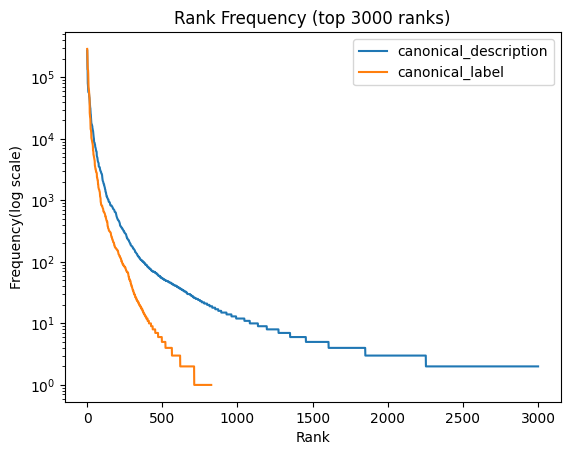

In [56]:
frequency_rank_plot(dataset_processed_pl, description="canonical_description", label="canonical_label")

- There is still a long tail for the descriptions, but this might be because the graph just shows the top 3000 ranks, so the tail isn't shown.

## 4.3 Word Count of Discriptions Distribution

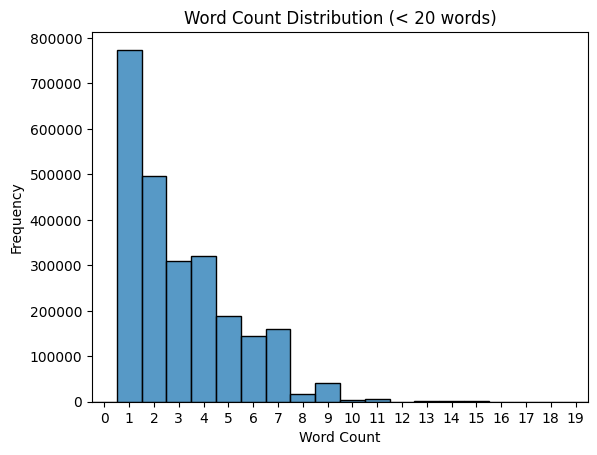

In [57]:
plot_word_count(dataset_processed_pl, "canonical_description")

- The rough bell shap has gone, this is because there are no longer any descriptions without any words, and many words have been replaced with single canonical word, increasing the the frequency of a single word.

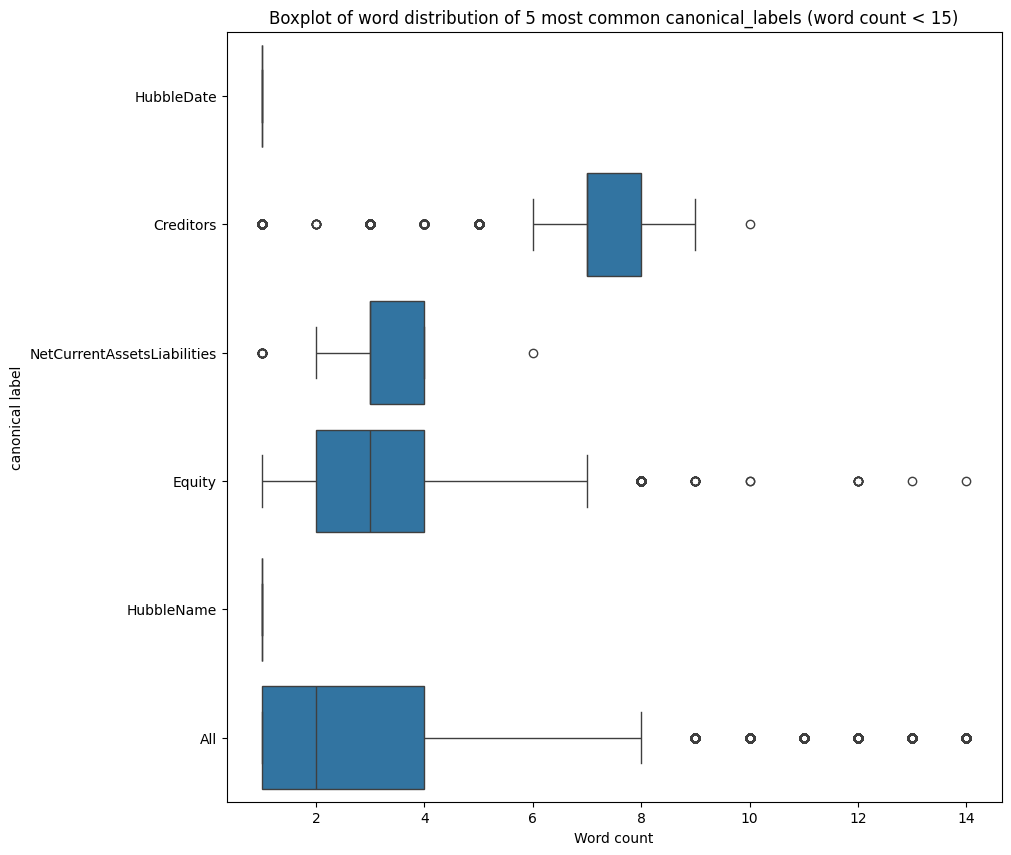

In [58]:
plot_word_distributions(dataset_processed_pl, description="canonical_description", label = "canonical_label")

- HubbleDate and HubbleName are now some of the most common labels, created through label engineering. They are related to just single words created through feature canonicalization.
- The distribution of all the words has moved left, reflecting that 1 word is now most common.
- The distribution of the other labels is mainly unchanged.

## 4.4 Samples of datasets

In [32]:
display_filtered_data(dataset_processed_pl, "canonical_description")

## Data extracts

## Sample

row_id,description,xbrl_concept,cleaned_description,canonical_description,canonical_label
u32,str,str,str,str,str
0,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate"""
1,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors"""
2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand"""
3,"""Creditors: Amounts Falling Due Within One Year""","""Creditors""","""creditors amounts falling due within one year""","""creditors amounts falling due within one year""","""Creditors"""
4,"""NET CURRENT ASSETS (LIABILITIES)""","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities"""
5,"""TOTAL ASSETS LESS CURRENT LIABILITIES""","""TotalAssetsLessCurrentLiabilities""","""total assets less current liabilities""","""total assets less current liabilities""","""TotalAssetsLessCurrentLiabilities"""
6,"""NET ASSETS""","""NetAssetsLiabilities""","""net assets""","""net assets""","""NetAssetsLiabilities"""
7,"""Income and Expenditure Account""","""Equity""","""income and expenditure account""","""income and expenditure account""","""Equity"""
8,"""R Tomlin Director""","""DirectorSigningFinancialStatements""","""r tomlin director""","""hubble_name""","""HubbleName"""


## Unique and common descriptions

canonical_description,n
str,u32
"""other debtors -card machine""",1
"""other debtors old church loan""",1
"""pension contribution""",1
"""other creditors - bjc investment""",1
"""interim dividend of £hubble_number hubble_number - £hubble_number per each c shares""",1
"""client's bank accounts""",1
"""profit and loss account - non distributable""",1
"""accruals - accountancy fees""",1
"""income recievable and similar income""",1


...

['amounts owed by group undertakings and undertakings in which the company has a participating interest',
 'monthly average number of persons employed by the company during the yearhubble_number including the director',
 'amounts owed to group undertakings and undertakings in which the company has a participating interest',
 'monthly average number of persons employed by the company during the financial yearhubble_number including directors',
 'the average number employed by the company including directors during the year hubble_number was hubble_number',
 'amounts owed by company undertakings and undertakings in which the company has a participating interest',
 'the average number of persons employed by the partnership during the period was hubble_number hubble_number',
 'monthly average number of persons employed by the company during the periodhubble_number including the director',
 'monthly average number of persons employed by the company during the financial periodhubble_number i

## Showing descriptions of length 16

'Noting with 16 words'

## Showing descriptions of length 17

'Noting with 17 words'

- Rather than having lots of names as uncommon descriptions you have the canonical token "hubble_name" as a common description.
- The junk description are either removed or replaced by a canonical token.


## 4.5 Pareto Chart

'Rank 95 percent 50'

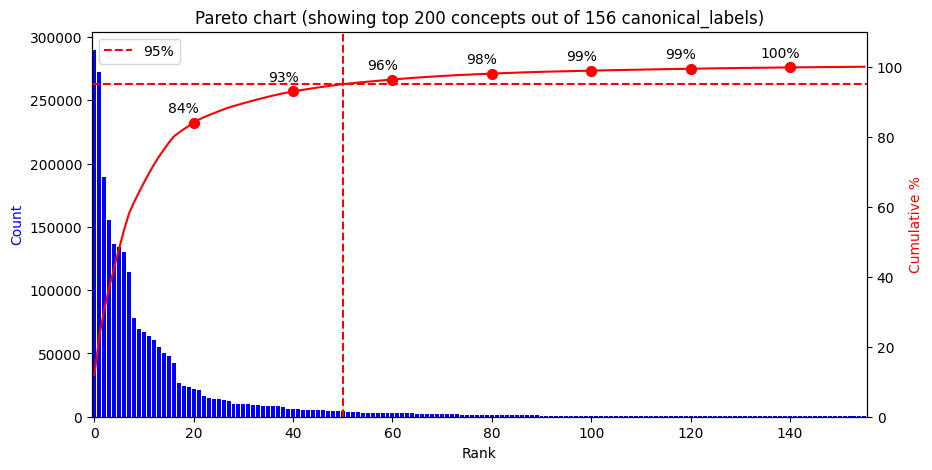

## Most commonly used concepts

,rank,canonical_label,len,percentage,log_count,cum_percentage
0,0,Equity,289755,0.118524,12.576794,0.118524
1,1,HubbleDate,272606,0.111510,12.515786,0.230034
2,2,Creditors,189293,0.077430,12.151057,0.307465
3,3,HubbleName,155418,0.063574,11.953880,0.371038
4,4,NetCurrentAssetsLiabilities,136597,0.055875,11.824798,0.426913
5,5,TotalAssetsLessCurrentLiabilities,134150,0.054874,11.806721,0.481788
6,6,HubbleNumber,129998,0.053176,11.775282,0.534963
7,7,NetAssetsLiabilities,113984,0.046625,11.643822,0.581589
8,8,CashBankOnHand,77906,0.031868,11.263271,0.613456
9,9,PropertyPlantEquipment,69453,0.028410,11.148420,0.641866


In [33]:
concept_balance_df = plot_pareto(dataset_processed_pl, label = "canonical_label")

- Due to the canonical labels, even fewer labels contain more of the data. 
- 95% of the data is covered by the top 50 labels

## 4.6 Powerlaw, Exponential, Lognormal

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 146/146 [00:00<00:00, 3520.61it/s]

Alpha: 1.4782065676745688, xmin: 300.0


## Powerlaw vs lognormal. R<0 makes it closer to lognormal

R: -2.892544770425907, and p: 0.11123180212973777


## Powerlaw vs exponential. R>0 makes it closer to powerlaw

R: 173.05100863275516, and p: 4.119677135287099e-12


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


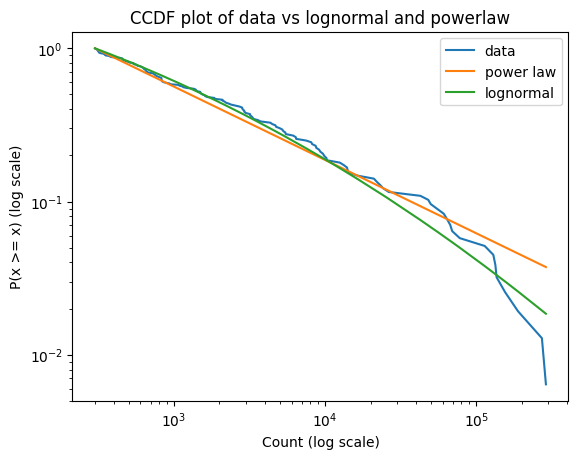

In [34]:
powerlaw_analysis(concept_balance_df)

- Slight less strong correlation to lognormal after preprocessing

## 4.7 Multiple XBRL Concepts per Description

In [35]:
all_labels_pl = (
    multi_mapping(dataset_processed_pl, "canonical_description", "canonical_label")
    .with_columns(pl.col("canonical_label").str.replace_all("([a-z])([A-Z])", "$1 $2").alias("canonical_label"))
)

multi_label_analysis(all_labels_pl, key="canonical_description", value="canonical_label")

## Multiple canonical_label per canonical_description

canonical_description,n_values,1,2,3,4,5,6,7,8,9
str,u32,str,str,str,str,str,str,str,str,str
"""director's loan account""",9,"""Further Item Creditors Component Total Creditors""","""Amounts Owed To Directors""","""Amounts Owed To Related Parties""","""Amounts Owed By Directors""","""Amounts Owed By Related Parties""","""Other Remaining Borrowings""","""Description Specific Advance Or Credit Its Conditions Indicative Interest Rate Directors""","""Total Borrowings""","""Further Item Debtors Component Total Debtors"""
"""loan""",9,"""Bank Overdrafts""","""Other Remaining Borrowings""","""Further Item Creditors Component Total Creditors""","""Bank Borrowings Overdrafts""","""Further Item Debtors Component Total Debtors""","""Amounts Owed To Associates Joint Ventures Participating Interests""","""Total Borrowings""","""Amounts Owed To Other Related Parties Other Than Directors""","""Description Specific Advance Or Credit Its Conditions Indicative Interest Rate Directors"""
"""loans""",9,"""Other Remaining Borrowings""","""Debtors""","""Bank Borrowings Overdrafts""","""Description Specific Advance Or Credit Its Conditions Indicative Interest Rate Directors""","""Other Debtors""","""Other Creditors""","""Total Borrowings""","""Further Item Creditors Component Total Creditors""","""Further Item Debtors Component Total Debtors"""
"""other creditors""",9,"""Amounts Owed To Other Related Parties Other Than Directors""","""Taxation Social Security Payable""","""Further Item Creditors Component Total Creditors""","""Amounts Owed To Related Parties""","""Other Remaining Borrowings""","""Other Creditors""","""Finance Lease Liabilities Present Value Total""","""Total Borrowings""","""Accrued Liabilities"""
"""additions""",8,"""Investments""","""Additions Other Than Through Business Combinations Intangible Assets""","""Investments In Subsidiaries""","""Total Additions Including From Business Combinations Intangible Assets""","""Additions Other Than Through Business Combinations Investment Property Fair Value Model""","""Additions Other Than Through Business Combinations Property Plant Equipment""","""Total Additions Including From Business Combinations Property Plant Equipment""","""Other Investments Other Than Loans""",null
"""corporation tax""",8,"""Tax Tax Credit On Profit Or Loss On Ordinary Activities""","""Debtors""","""Other Creditors""","""Other Debtors""","""Further Item Debtors Component Total Debtors""","""Corporation Tax Payable""","""Taxation Social Security Payable""","""Corporation Tax Recoverable""",null
"""directors loan account""",8,"""Amounts Owed By Related Parties""","""Amounts Owed To Directors""","""Amounts Owed By Directors""","""Total Borrowings""","""Other Remaining Borrowings""","""Description Specific Advance Or Credit Its Conditions Indicative Interest Rate Directors""","""Other Creditors""","""Amounts Owed To Related Parties""",null
"""hubble_date and hubble_date""",8,"""Equity""","""Accumulated Amortisation Impairment Intangible Assets""","""Start Date For Period Covered By Report""","""Property Plant Equipment Gross Cost""","""Investments In Subsidiaries""","""Intangible Assets Gross Cost""","""Investments""","""Investment Property Fair Value Model""",null
"""other loans""",8,"""Bank Borrowings""","""Further Item Debtors Component Total Debtors""","""Other Remaining Borrowings""","""Total Borrowings""","""Amounts Owed To Other Related Parties Other Than Directors""","""Other Creditors""","""Bank Borrowings Overdrafts""","""Further Item Creditors Component Total Creditors""",null


- The descriptions are all very generic like "additions", and it makes sense for there to be multiple concepts to be linked to each description
- "loans" have various concepts like "Debors", "Other Creditors", "Total Borrowings", etc., which makes sense but it means there isn't enough data to correclty categorise those items. 

### 4.7.1 Similarity of XBRL Concepts

In [36]:
sim_pl = show_overlap_similarity(all_labels_pl, key="canonical_description", value="canonical_label")

index,canonical_description,canonical_label,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
1345,"""taxation and social security costs""","""Taxation Social Security Payable""",2,1,0.8944,0.8944
1346,"""taxation and social security costs""","""Other Taxation Social Security Payable""",2,2,0.8944,0.8944
749,"""#name?""","""Net Current Assets Liabilities""",2,1,0.866,0.866
750,"""#name?""","""Net Assets Liabilities""",2,2,0.866,0.866
1125,"""net liabilities""","""Net Current Assets Liabilities""",2,1,0.866,0.866
1126,"""net liabilities""","""Net Assets Liabilities""",2,2,0.866,0.866
879,"""carrying amount hubble_date""","""End Date For Period Covered By Report""",2,1,0.8571,0.8571
880,"""carrying amount hubble_date""","""Start Date For Period Covered By Report""",2,2,0.8571,0.8571
915,"""company has a participating interest""","""Amounts Owed By Group Undertakings Participating Interests""",2,1,0.8571,0.8571


index,canonical_description,canonical_label,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
173,"""amounts owed to group undertakings""","""Amounts Owed To Other Related Parties Other Than Directors""",6,1,0.4334,0.3824
174,"""amounts owed to group undertakings""","""Amounts Owed To Related Parties""",6,2,0.4511,0.3824
175,"""amounts owed to group undertakings""","""Amounts Owed To Group Undertakings""",6,3,0.4648,0.3824
176,"""amounts owed to group undertakings""","""Other Creditors""",6,4,0.0853,0.3824
177,"""amounts owed to group undertakings""","""Amounts Owed To Group Undertakings Participating Interests""",6,5,0.4725,0.3824
178,"""amounts owed to group undertakings""","""Amounts Owed To Associates Joint Ventures Participating Interests""",6,6,0.3873,0.3824
36,"""additions""","""Investments""",8,1,0.1365,0.2776
37,"""additions""","""Additions Other Than Through Business Combinations Intangible Assets""",8,2,0.3895,0.2776
38,"""additions""","""Investments In Subsidiaries""",8,3,0.1137,0.2776


index,canonical_description,canonical_label,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64


- Some descriptions, like "amounts owed to group undertakings" had a number of similar concepts both in similarity and meaning "Amounts Owed To Related Parties" "Amounts Owed To Group Undertakings" "Amounts Owed To Other Related Parties Other Than Directors" "Amounts Owed To Group Undertakings Participating Interests" "Amounts Owed To Associates Joint Ventures Participating Interests"
    - While using the related party concept is correct in a technical sense, the group one should be the one used. 
    - While talking about amounts owed to assoicate joint ventures would be a correct tag to use, it would required advanced accountancy knowledge that most analysts don't have.
    - This might be a situation where a more consitent ML category can improve analysis even over the iXBRL data, not just untagged data.
    - Even if adding more features does allow us to discriminate between the concepts, there is a desire to have simplified groupings. The business has complex bespoke mapping of various concepts to a simplified category list. So potentially longer term that might be something we might to have a two labels, one detailed and another simplieifed concept. 
- "hubble_date and hubble_date"	is related to multiple concepts. While pure dates and other simple itterations of dates have had feature engineering, this hasn't. On future itterations this should be handled.
- "current assets" had a group similarity score of 0.2162, which isn't the highest but isn't very low, with words like assets showing similarty between variosu concepts. "Current Assets", "Cash Bank On Hand", "Debtors", "Net Current Assets Liabilities", "Fixed Assets", "Net Assets Liabilities". In accountancy terms these concepts are very similar. Maybe if using an embedding or accountancy specific embedding then the similarity scores would be even higher than just the tfidf cosine similarity based scores.
- "additions" relataed to concepts about additions but of very different items. So while it had a higher similarity score, 0.2776, then "current assets" that's just based on having the same words rather than meaning. 


## 4.8 Multiple Descriptions per XBRL Concept

In [37]:
multi_labels_pl = multi_mapping(dataset_processed_pl, "canonical_label", "canonical_description")

multi_label_analysis(multi_labels_pl, key="canonical_label", value="canonical_description", rows=20)

## Multiple canonical_description per canonical_label

canonical_label,n_values,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,…,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629
str,u32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""FurtherItemCreditorsComponentTotalCreditors""",629,"""other creditors - dwp dea""","""hubble_company_name loan""","""nottingham mortgage - hubble_number ennerdale""","""unpaid pension contributions""","""income in advance""","""american express business card-hubble_number""","""land rover hp""","""residents funds""","""other creditors - business credit card""","""accrued pension payments""","""g & r home improvements loan account""","""other creditors - john hartley""","""funding circle more than hubble_number yr""","""attachments creditor""","""private loan long term liabilities - creditors > hubble_number year""","""swig loan""","""directors' current account""","""inter company account""","""dla - sj""","""energy saving trust loan""","""dividends payable - equity""","""capital ontap""","""other creditors - owed to service charge""","""energy saving trust loan <hubble_number year""","""other creditors hubble_number current liabilities - creditors < hubble_number year""","""hire purchase loan""","""voucher unallocated""","""other creditors - pension liability""","""pension loan""","""paye and ni""","""nest payable""","""filtex intercompany loan""","""hubble_company_name loan account""","""provision for rent""","""shares classed as financial liabilities""",…,"""other creditors mkn property holdings""","""other creditors - cis""","""other creditors propel finance""","""other creditors'""","""paypal""","""other creditors - barrhead""","""credit card - american express""","""director's loan account""","""pension control""","""cbil""","""convertible loan""","""raisins hill invest""","""current loan koh""","""equipment finance >hubble_numberyr""","""pension scheme""","""third party loan - marvella lecointe""","""other creditors hhubble_numberphubble_number""","""other creditors -""","""j h hub loan account""","""fiona granelli loan""","""salary & wages creditor""","""associated entities loan accounts - long term""","""kingsway asset finance""","""intercompany account""","""private markets advisors sarl - loan""","""members short term loans""","""hubble_company_name - kennie properties""","""shareholders loan""","""sub contractor fees current liabilities - creditors < hubble_number year""","""stocking finance""","""bond creditor""","""nest hubble_number current liabilities - creditors < hubble_number year""","""other borrowings""","""other creditors goodfella beckenham""","""other creditors sqp loan""","""other creditors - credit card""","""other creditor- pensions payable"""
"""AdvancesCreditsDirectors""",554,"""d w huskison""","""m durbin""","""paul rossi""","""miss sharon savanhu""","""dr bilal ahmed""","""miss lisa everitt""","""miss michelle wong""","""a p tanna""","""melanie swan""","""shabnam ramzan""","""p evans""","""laurence rapp""","""miss hannah field""","""w d bew""","""o a sattar""","""miss andrea grimes""","""dr christopher ainsworth""","""rachel matthews""","""iain weaver""","""miss jagjit virdee""","""zoe allen""","""k d brown""","""r hooper""","""miss georgia dawson""","""dr durr-e-najaf siddique""","""duncan eugenio iraci""","""dr john carey""","""j l adams""","""p n stephens""","""g k brar""","""amar mehta""","""miss siobhan flynn""","""miss cheryl robinson""","""miss katie woodward""","""k lobo""",…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,

- "AdvancesCreditsDirectors" actually had lots of directors names, they didn't have a Mr/Mrs prefix so weren't cought by preprocessing. 
    - Could add additional name detection, maybe using a list of actual names
    - Should also act on this iXBRL concept directly and just replace everything there with a placeholder. @TODO see what other concepts have Directors in the name that need similar treatment. 
- "DescriptionDepreciationMethodForPropertyPlantEquipment" has lots of descriptions, which makes sense since it's a description concept. 
- "Equity" has lots of varied descriptions, which makes sense. But it does highlight the issue that if just using the pure iXBRL data there is a lot of information(descriptions) which you don't have available for analysis. So while categorising descriptions will be useful for some analysis you might want to use the actual description. 

In [38]:
show_overlap_similarity(multi_labels_pl, "canonical_label", "canonical_description")

index,canonical_label,canonical_description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
6514,"""OtherTaxationPayable""","""other taxation and social security""",2,1,0.8944,0.8944
6515,"""OtherTaxationPayable""","""taxation and social security""",2,2,0.8944,0.8944
6504,"""AccountingStandardsApplied""","""the accounts were prepared in accordance with frshubble_number""",2,1,0.875,0.875
6505,"""AccountingStandardsApplied""","""the accounts were prepared in accordance with frshubble_numbera""",2,2,0.875,0.875
4454,"""NumberSharesAllotted""","""hubble_number ordinary class b shares of £hubble_number each""",79,1,0.857,0.821
4455,"""NumberSharesAllotted""","""hubble_number c shares of £hubble_number each""",79,2,0.8653,0.821
4456,"""NumberSharesAllotted""","""hubble_number class m share of £hubble_number each""",79,3,0.8198,0.821
4457,"""NumberSharesAllotted""","""hubble_number ordinary class shares of £hubble_number each""",79,4,0.857,0.821
4458,"""NumberSharesAllotted""","""hubble_number ordinary share of £ hubble_number each""",79,5,0.8285,0.821


index,canonical_label,canonical_description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
4454,"""NumberSharesAllotted""","""hubble_number ordinary class b shares of £hubble_number each""",79,1,0.857,0.821
4455,"""NumberSharesAllotted""","""hubble_number c shares of £hubble_number each""",79,2,0.8653,0.821
4456,"""NumberSharesAllotted""","""hubble_number class m share of £hubble_number each""",79,3,0.8198,0.821
4457,"""NumberSharesAllotted""","""hubble_number ordinary class shares of £hubble_number each""",79,4,0.857,0.821
4458,"""NumberSharesAllotted""","""hubble_number ordinary share of £ hubble_number each""",79,5,0.8285,0.821
4459,"""NumberSharesAllotted""","""hubble_number ordinary b share of £hubble_number each""",79,6,0.8285,0.821
4460,"""NumberSharesAllotted""","""hubble_number class hubble_number shares of £hubble_number each""",79,7,0.8653,0.821
4461,"""NumberSharesAllotted""","""hubble_number redeemable preference shares of £hubble_number each""",79,8,0.766,0.821
4462,"""NumberSharesAllotted""","""hubble_number class n share of £hubble_number each""",79,9,0.8198,0.821


index,canonical_label,canonical_description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
4454,"""NumberSharesAllotted""","""hubble_number ordinary class b shares of £hubble_number each""",79,1,0.857,0.821
4455,"""NumberSharesAllotted""","""hubble_number c shares of £hubble_number each""",79,2,0.8653,0.821
4456,"""NumberSharesAllotted""","""hubble_number class m share of £hubble_number each""",79,3,0.8198,0.821
4457,"""NumberSharesAllotted""","""hubble_number ordinary class shares of £hubble_number each""",79,4,0.857,0.821
4458,"""NumberSharesAllotted""","""hubble_number ordinary share of £ hubble_number each""",79,5,0.8285,0.821
4459,"""NumberSharesAllotted""","""hubble_number ordinary b share of £hubble_number each""",79,6,0.8285,0.821
4460,"""NumberSharesAllotted""","""hubble_number class hubble_number shares of £hubble_number each""",79,7,0.8653,0.821
4461,"""NumberSharesAllotted""","""hubble_number redeemable preference shares of £hubble_number each""",79,8,0.766,0.821
4462,"""NumberSharesAllotted""","""hubble_number class n share of £hubble_number each""",79,9,0.8198,0.821


index,canonical_label,canonical_description,n_values,n,indiv_group_sim,group_sim
u32,str,str,u32,u32,f64,f64
6514,"""OtherTaxationPayable""","""other taxation and social secu…",2,1,0.8944,0.8944
6515,"""OtherTaxationPayable""","""taxation and social security""",2,2,0.8944,0.8944
6504,"""AccountingStandardsApplied""","""the accounts were prepared in …",2,1,0.875,0.875
6505,"""AccountingStandardsApplied""","""the accounts were prepared in …",2,2,0.875,0.875
4454,"""NumberSharesAllotted""","""hubble_number ordinary class b…",79,1,0.857,0.821
…,…,…,…,…,…,…
6509,"""DisposalsIntangibleAssets""","""disposals""",2,2,0.0,0.0
6516,"""TotalIncreaseDecreaseFromReval…","""revaluations""",2,1,0.0,0.0
6517,"""TotalIncreaseDecreaseFromReval…","""transfers from group companies""",2,2,0.0,0.0


- "NumberSharesAllotted" has a lot of very similar descriptions	such as "hubble_number c shares of £hubble_number each", "hubble_number class m share of £hubble_number each", "hubble_number ordinary class shares of £hubble_number each"
    - There are soo many variations that it will rely on the ML to pick them up, and the high group similarity means there should be a clear signal that it can do that with. But replacing actual numbers with hubble_number, reduces the noise and should make it easier to ML to categorise all the variations.
- "Investments" has lots of varied descriptions with low group similarity, which makes sense. 
- "WagesSalaries" had a low group similarity with descriptions "remuneration" and "wages and salaries". But those do have similar meanings even though there is no overlap in words. Maybe better accountancy embeddings would show high similarity. 	

# 5. Embeddings
Basic analysis of different embeddings working over a sample.  
TFIDF 1-3 word ngrams.  
TF 1-3 word ngrams.  
TF 1-3 word ngrams & 3-5 character ngrams.  
SBERT "all-mpnet-base-v2".  
E5 "intfloat/e5-large-v2".  

In [20]:
sample_pl = dataset_processed_pl.sample(n=50_000, seed=SEED).with_columns(
    pl.col("xbrl_concept").str.replace_all("([a-z])([A-Z])", "$1 $2")
)
sample_descriptions=sample_pl.get_column("canonical_description").to_list()

In [10]:
model_e5 = SentenceTransformer("intfloat/e5-base-v2", device="mps")
model_mpnet = SentenceTransformer("all-mpnet-base-v2", device="mps")
model_mini = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="mps")

In [11]:
vectorizer_tfidf_word = TfidfVectorizer(lowercase=True, ngram_range=(1, 3), use_idf=False, norm = "l2")
embeddings_tfidf_word = vectorizer_tfidf_word.fit_transform(sample_descriptions)

In [12]:
vectorizer_tf_word = TfidfVectorizer(lowercase=True, ngram_range=(1, 3), use_idf=False, norm = "l2")
embeddings_tf_word = vectorizer_tf_word.fit_transform(sample_descriptions)

In [13]:
# Wrapped in pipelines to get rid of warnings
vectorizer_tf_word_char = FeatureUnion(
    [
        (
            "word",
            TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 3),
                lowercase=True,
                min_df=2,
                norm=None,  # Since there are two parts, just do the norm as the normalizer don't want to do it here
                use_idf=False,
            ),
        ),
        (
            "char",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                lowercase=True,
                min_df=2,
                norm=None,
                use_idf=False,
            ),
        ),
    ]
)

pipeline_tf_word_char = Pipeline([("features", vectorizer_tf_word_char), ("normalize", Normalizer(norm="l2"))])

embeddings_tf_word_char = pipeline_tf_word_char.fit_transform(sample_descriptions)

In [27]:
embeddings_mpnet = model_mpnet.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

embeddings_mini = model_mini.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

embeddings_e5 = model_e5.encode(
    sample_descriptions,
    normalize_embeddings=True, 
    batch_size=256,
    show_progress_bar=True,
)

Batches: 100%|██████████| 196/196 [00:08<00:00, 22.46it/s]


In [ ]:
score_tfidf_word = silhouette_score(embeddings_tfidf_word, sample_pl.get_column("canonical_label"))
display(f"Tfidf word: {score_tfidf_word}")

score_tf_word = silhouette_score(embeddings_tf_word, sample_pl.get_column("canonical_label"))
display(f"Tf word: {score_tf_word}")

score_tf_word_char = silhouette_score(embeddings_tf_word_char, sample_pl.get_column("canonical_label"))
display(f"Tf word char: {score_tf_word_char}")

score_mpnet = silhouette_score(embeddings_mpnet, sample_pl.get_column("canonical_label"))
display(f"MPNET: {score_mpnet}")

score_mini = silhouette_score(embeddings_mini, sample_pl.get_column("canonical_label"))
display(f"MINI: {score_mini}")

score_e5 = silhouette_score(embeddings_e5, sample_pl.get_column("canonical_label"))
display(f"E5: {score_e5}")




'Tfidf word: 0.41859270152836814'

'Tf word: 0.41859270152836814'

'Tf word char: 0.43613920726118666'

'MPNET: 0.46723347902297974'

'MINI: 0.4408533275127411'

'E5: 0.43277034163475037'

The sihouette scores are fairly close from 0.419 to 0.467.  
TFIDF didn't have any advantage over TF. 
With TF with 1-3 word ngrams with 3-5 character ngrams scored 0.44, which showed that adding character embeddings improved performance.  
Mpnet performed best, with a score of 0.47  

This is just a score over a sample, and the close scores it doesn't definitevely say which would be better for a model, it might depend on the model. It is worth trying the models both on the top scoring TF and mpnet embeddings.  

There are lots of potential options for TF/TFIDF, try grid search to try various options.

In [ ]:
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        norm=None,
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        norm=None,
    )),
])

pipe = Pipeline([
    ("features", vectorizer),
    ("normalize", Normalizer(norm="l2")),
])

param_grid = [
    # Words only
    {
        "features__char": ["drop"],
        "features__word__ngram_range": [(1,1), (1,2), (1,3), (1,4)],
        "features__word__min_df": [1,2,5],
        "features__word__use_idf": [True, False],
    },
    # Word and chars
    {
        "features__char__ngram_range": [(2,6), (3,4), (3,5), (3,6)],
        "features__char__min_df": [1,2,5],
        "features__char__use_idf": [True, False],
        "features__word__ngram_range": [(1,1), (1,2), (1,3), (1,4)],
        "features__word__min_df": [1,2,5],
        "features__word__use_idf": [True, False],
    }
]

def silhouette_scorer(estimator, X, y) -> float | np.floating:
    score = silhouette_score(estimator.transform(X), y, metric="cosine")
    print(score)
    return score

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=silhouette_scorer,
    n_jobs=-1, # Use all cores
    verbose=2
)

grid_search.fit(sample_descriptions, sample_pl.get_column("canonical_label"))
print(grid_search.best_params_)
print(grid_search.best_score_)


Fitting 5 folds for each of 600 candidates, totalling 3000 fits


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

0.42269290466915344
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=False; total time=   6.6s
0.49888208836367715
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=True; total time=   6.8s
0.3955249305758717
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=True; total time=   6.9s
0.478061866688087
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=False; total time=   7.0s
0.5138185143726727
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=True; total time=   7.0s
0.4477643836085163
[CV] END features__char=drop, features__word__min_df=1, features__word__ngram_range=(1, 1), features__word__use_idf=True; total time=   7.1s
0.4687381307222242
[CV] END features_

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.40963654361202845
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=True; total time=   0.7s
0.5015092091178087
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=True; total time=   0.7s
0.5271162723855037
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=True; total time=   0.7s
0.39027066279870415
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   0.7s
0.46677614742848145
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=True; total time=   0.7s
0.44699059597320373
[CV] END features__char=drop, features__word__min_df=2, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   0.7s
0.4936995294797046
[CV] END featur

...

0.5048863819000451
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=True, features__word__min_df=1, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   3.4s


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.4013425924619823
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=True, features__word__min_df=1, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   3.5s
0.4203251383829869
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=True, features__word__min_df=1, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   3.5s
0.5210393515670875
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=True, features__word__min_df=1, features__word__ngram_range=(1, 2), features__word__use_idf=False; total time=   3.6s
0.5161257992091616
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=True, features__word__min_df=1, features__word__ngram_range=(1, 3), features__word__use_idf=True; total time=   3.8s
0.5200265215041004
[CV] END features__char__min_df=1, features__char__ngr

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


0.4842309165657207
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=False, features__word__min_df=2, features__word__ngram_range=(1, 3), features__word__use_idf=False; total time=   4.2s
0.38389206522143265
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=False, features__word__min_df=2, features__word__ngram_range=(1, 3), features__word__use_idf=False; total time=   4.0s
0.4083146932096014
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=False, features__word__min_df=2, features__word__ngram_range=(1, 3), features__word__use_idf=False; total time=   4.1s
0.5044182788008398
[CV] END features__char__min_df=1, features__char__ngram_range=(2, 6), features__char__use_idf=False, features__word__min_df=2, features__word__ngram_range=(1, 3), features__word__use_idf=False; total time=   4.2s
0.5441131991710701
[CV] END features__char__min_df=1, features__cha

In [ ]:
best_model = grid_search.best_estimator_

embeddings_ngrams = best_model.transform(sample_descriptions)

score_ngrams = silhouette_score(embeddings_ngrams, sample_pl.get_column("canonical_label"))
display(f"Silhouette Score: {score_ngrams}")

'E5: 0.47650171153193244'

The top score was the following. This might be a good starting point for any models, but the actual best parameters will need to be evaluated on actual models.
{'features__char__min_df': 1, 'features__char__ngram_range': (3, 4), 'features__char__use_idf': False, 'features__word__min_df': 1, 'features__word__ngram_range': (1, 2), 'features__word__use_idf': True}
0.477

Actually had the best score beating sentence embeddings

Interesting that word uses idf but not for characters. So you might have words like "of, in, then", which don't carry as much meaning but are frequently used, so idf reduces their importance which helps. Wheras you don't have something that similar on a character level. 

I would have through word ngram 1-3 would have been better than 1-2, but I guess it might just add noise. 

This did even better than the sentence embeddings.

### Summary

- n-grams after gridsearch to find the optimum hyper parameters combining ngram of words and character, had a slightly better silhouette score than sentence embeddings. 



# 6. Split and save data

In [8]:
def stratified_split(
    dataset_processed_pl: pl.DataFrame,
    label: str = "canonical_label",
    train_fraction: float = 0.8,
    test_fraction: float = 0.1,
) -> pl.DataFrame:
    """Adds split column saying if it belongs to train, best or holdout

    Args:
        dataset_processed_pl (pl.DataFrame): Dataset
        label (str, optional): Column name for the label. Defaults to "canonical_label".
        train_fraction (float, optional): Fraction of train. Defaults to 0.8.
        test_fraction (float, optional): Fraction of test. Defaults to 0.1.

    Returns:
        pl.DataFrame: Dataset with split column
    """

    min_examples = dataset_processed_pl["min_examples"].to_numpy()

    idx = np.arange(dataset_processed_pl.height)[min_examples]
    y = dataset_processed_pl.get_column(label).to_numpy()[min_examples]

    idx_train, idx_temp, y_train, y_temp = train_test_split(
        idx, y, test_size=(1 - train_fraction), stratify=y, random_state=SEED
    )

    idx_test, idx_holdout, y_test, y_holdout = train_test_split(
        idx_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )

    idx_10_pct_holdout, idx_holdout_rest = train_test_split(
        idx_holdout, test_size=0.9, stratify=y_holdout, random_state=SEED
    )

    holdout_10_pct = np.full(dataset_processed_pl.height, False)
    holdout_10_pct[idx_10_pct_holdout] = True

    split = np.full(dataset_processed_pl.height, "excluded")
    split[min_examples] = "holdout"
    split[idx_train] = "train"
    split[idx_test] = "test"

    # Add a 5 pct column for faster BERT testing
    idx_5_pct, _ = train_test_split(
        idx_test,
        test_size=0.95,
        stratify=dataset_processed_pl[idx_test].get_column(label).to_numpy(),
        random_state=SEED,
    )

    test_5_pct = np.full(dataset_processed_pl.height, False)
    test_5_pct[idx_5_pct] = True

    return dataset_processed_pl.with_columns(
        pl.Series("split", split),
        pl.Series("test_5_pct", test_5_pct),
        pl.Series("train", split == "train"),
        pl.Series("test", split == "test"),
        pl.Series("holdout_10_pct", holdout_10_pct),
        pl.Series("holdout", split == "holdout"),
    )


dataset_split_pl = stratified_split(dataset_processed_pl)


In [9]:
dataset_split_pl.filter(pl.col("holdout_10_pct")).pipe(display)

row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
6,2,"""NET ASSETS""","""NetAssetsLiabilities""","""net assets""","""net assets""","""NetAssetsLiabilities""",true,"""holdout""",false,false,false,true,true
88,106,"""Tangible assets""","""PropertyPlantEquipment""","""tangible assets""","""tangible assets""","""PropertyPlantEquipment""",true,"""holdout""",false,false,false,true,true
356,8,"""Called up share capital""","""Equity""","""called up share capital""","""called up share capital""","""Equity""",true,"""holdout""",false,false,false,true,true
367,2,"""Mr Symon Claxton Designated M…","""DirectorSigningFinancialStatem…","""mr symon claxton designated me…","""hubble_name""","""HubbleName""",true,"""holdout""",false,false,false,true,true
390,1,"""Company Registration Number:""","""UKCompaniesHouseRegisteredNumb…","""company registration number""","""company registration number""","""UKCompaniesHouseRegisteredNumb…",true,"""holdout""",false,false,false,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2465482,1,"""Approved by the board on 20 No…","""DateAuthorisationFinancialStat…","""approved by the board on 20 no…","""approved by the board hubble_d…","""DateAuthorisationFinancialStat…",true,"""holdout""",false,false,false,true,true
2465586,1,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""holdout""",false,false,false,true,true
2465607,5,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true,"""holdout""",false,false,false,true,true


In [10]:
dataset_split_pl.filter(pl.col("train")).pipe(display)
dataset_split_pl.filter(pl.col("split")=="train").pipe(display)
dataset_split_pl.filter(pl.col("split")=="test").pipe(display)
dataset_split_pl.filter(pl.col("split")=="holdout").pipe(display)
dataset_split_pl.filter(pl.col("split")=="excluded").pipe(display)
dataset_split_pl.filter(pl.col("test_5_pct")).pipe(display)

row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""train""",false,true,false,false,false
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466046,16,"""At 28 February 2025""","""PropertyPlantEquipment""","""at 28 february 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false
2466048,18,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true,"""train""",false,true,false,false,false
2466049,20,"""Taxation and social security""","""TaxationSocialSecurityPayable""","""taxation and social security""","""taxation and social security""","""TaxationSocialSecurityPayable""",true,"""train""",false,true,false,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""train""",false,true,false,false,false
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466046,16,"""At 28 February 2025""","""PropertyPlantEquipment""","""at 28 february 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false
2466048,18,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true,"""train""",false,true,false,false,false
2466049,20,"""Taxation and social security""","""TaxationSocialSecurityPayable""","""taxation and social security""","""taxation and social security""","""TaxationSocialSecurityPayable""",true,"""train""",false,true,false,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
17,1,"""Net assets/(liabilities)""","""NetAssetsLiabilities""","""net assets/liabilities""","""net assets/liabilities""","""NetAssetsLiabilities""",true,"""test""",false,false,true,false,false
29,1,"""The accounts have been audited""","""AccountsStatusAuditedOrUnaudit…","""the accounts have been audited""","""the accounts have been audited""","""AccountsStatusAuditedOrUnaudit…",true,"""test""",false,false,true,false,false
30,1,"""Alexander Irving""","""DirectorSigningFinancialStatem…","""alexander irving""","""hubble_name""","""HubbleName""",true,"""test""",false,false,true,false,false
37,7,"""During the year, the average n…","""AverageNumberEmployeesDuringPe…","""during the year, the average n…","""during the yearhubble_number t…","""AverageNumberEmployeesDuringPe…",true,"""test""",false,false,true,false,false
46,98,"""NET CURRENT ASSETS""","""NetCurrentAssetsLiabilities""","""net current assets""","""net current assets""","""NetCurrentAssetsLiabilities""",true,"""test""",false,false,true,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2465992,1,"""Total assets less current liab…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""test""",true,false,true,false,false
2466015,4,"""As at 1 May 2024""","""AccumulatedDepreciationImpairm…","""as at 1 may 2024""","""hubble_date""","""HubbleDate""",true,"""test""",false,false,true,false,false
2466024,6,"""Accrued expenses""","""AccruedLiabilitiesDeferredInco…","""accrued expenses""","""accrued expenses""","""AccruedLiabilitiesDeferredInco…",true,"""test""",false,false,true,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
3,2,"""Creditors: Amounts Falling Due…","""Creditors""","""creditors amounts falling due …","""creditors amounts falling due …","""Creditors""",true,"""holdout""",false,false,false,false,true
6,2,"""NET ASSETS""","""NetAssetsLiabilities""","""net assets""","""net assets""","""NetAssetsLiabilities""",true,"""holdout""",false,false,false,true,true
10,3,"""29/11/2025""","""DateAuthorisationFinancialStat…","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""holdout""",false,false,false,false,true
21,1,"""06932223""","""UKCompaniesHouseRegisteredNumb…","""06932223""","""hubble_number""","""HubbleNumber""",true,"""holdout""",false,false,false,false,true
26,1,"""false""","""EntityDormantTruefalse""","""false""","""false""","""EntityDormantTruefalse""",true,"""holdout""",false,false,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466012,3,"""Computer Equipment""","""DescriptionDepreciationMethodF…","""computer equipment""","""computer equipment""","""DescriptionDepreciationMethodF…",true,"""holdout""",false,false,false,false,true
2466014,4,"""As at 30 April 2025""","""PropertyPlantEquipmentGrossCos…","""as at 30 april 2025""","""hubble_date""","""HubbleDate""",true,"""holdout""",false,false,false,false,true
2466038,11,"""Fixtures and fittings""","""DescriptionDepreciationMethodF…","""fixtures and fittings""","""fixtures and fittings""","""DescriptionDepreciationMethodF…",true,"""holdout""",false,false,false,false,true


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
328,9,"""Amounts owed to parent underta…","""AmountsOwedToParentEntities""","""amounts owed to parent underta…","""amounts owed to parent underta…","""AmountsOwedToParentEntities""",false,"""excluded""",false,false,false,false,false
334,13,"""Interim dividend paid""","""InterimDividendsPaid""","""interim dividend paid""","""interim dividend paid""","""InterimDividendsPaid""",false,"""excluded""",false,false,false,false,false
690,11,"""Interim dividend paid""","""InterimDividendsPaid""","""interim dividend paid""","""interim dividend paid""","""InterimDividendsPaid""",false,"""excluded""",false,false,false,false,false
762,1,"""Average number of employees:""","""FurtherDepartmentItemAverageNu…","""average number of employees""","""average number of employees""","""FurtherDepartmentItemAverageNu…",false,"""excluded""",false,false,false,false,false
1089,7,"""Cash at bank""","""BalancesWithBanks""","""cash at bank""","""cash at bank""","""BalancesWithBanks""",false,"""excluded""",false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2464805,11,"""2025-11-19 …","""DateAccountantsReport""","""2025-11-19 date 19 november 20…","""hubble_date date hubble_date""","""DateAccountantsReport""",false,"""excluded""",false,false,false,false,false
2464810,13,"""Other charges""","""OtherExternalCharges""","""other charges""","""other charges""","""OtherExternalCharges""",false,"""excluded""",false,false,false,false,false
2464996,1,"""Sales, marketing and distribut…","""SalesMarketingDistributionAver…","""sales, marketing and distribut…","""saleshubble_number marketing a…","""SalesMarketingDistributionAver…",false,"""excluded""",false,false,false,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool
461,101,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""test""",true,false,true,false,false
512,6,"""Trade creditors""","""TradeCreditorsTradePayables""","""trade creditors""","""trade creditors""","""TradeCreditorsTradePayables""",true,"""test""",true,false,true,false,false
822,119,"""Called up share capital""","""Equity""","""called up share capital""","""called up share capital""","""Equity""",true,"""test""",true,false,true,false,false
953,113,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""test""",true,false,true,false,false
965,166,"""Mr T Lockhart - Director""","""NameEntityOfficer""","""mr t lockhart - director""","""hubble_name""","""HubbleName""",true,"""test""",true,false,true,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2465150,53,"""Amounts falling due within one…","""Creditors""","""amounts falling due within one…","""amounts falling due within one…","""Creditors""",true,"""test""",true,false,true,false,false
2465601,4,"""As at 31 March 2025""","""PropertyPlantEquipmentGrossCos…","""as at 31 march 2025""","""hubble_date""","""HubbleDate""",true,"""test""",true,false,true,false,false
2465899,90,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""test""",true,false,true,false,false


In [11]:
def sample_split(
    dataset_split_pl: pl.DataFrame, feature: str = "canonical_description", label: str = "canonical_label"
) -> pl.DataFrame:
    """Adds columns for unique, 1%, 10%, 50% and 100% samples

    Args:
        df (pl.DataFrame): Dataset
        feature (str, optional): Column name of the feature. Defaults to "canonical_description".
        label (str, optional): Column name of the label. Defaults to "canonical_label".

    Returns:
        pl.DataFrame: Dataset with columns for sample types from DataSample
    """

    df = dataset_split_pl.drop("row_id", strict=False).with_row_index("row_id")

    train_pl = df.filter(pl.col("split") == "train")

    idx_train = train_pl.get_column("row_id").to_numpy()
    y = df[idx_train].get_column(label).to_numpy()

    def samples_bool(sample: DataSample, idx_rows: np.ndarray, y: np.ndarray, current_fraction: float | np.floating=1.0):
        if sample.fraction == 1:
            sample_array = np.full(df.height, False)
            sample_array[idx_rows] = True
            return sample_array, idx_rows

        if sample.fraction is None:
            return None, None

        test_fraction = (1 - sample.fraction/current_fraction)
        idx_sample, idx_not_sample = train_test_split(
            idx_rows,
            test_size=test_fraction,
            stratify=y,
            random_state=SEED,
        )
        sample_array = np.full(df.height, False)
        sample_array[idx_sample] = True
        return sample_array, idx_sample

    new_cols: list[pl.Series] = []

    idx_rows = idx_train
    current_fraction = 1.0
    for sample in DataSample:
        sample_array, idx_rows = samples_bool(sample, idx_rows, y, current_fraction)
        
        if sample_array is None:
            continue

        current_fraction = sample.fraction 

        new_cols.append(pl.Series(sample.label, sample_array))
        
        y = df[idx_rows].get_column(label).to_numpy()

    return df.with_columns(
        *new_cols,
        pl.when(pl.col("split") == "train")
        .then(pl.int_range(0, pl.len()).over(feature, label) == 0)
        .otherwise(True)
        .alias("sample_unique"),
    )


dataset_sample_split_pl = sample_split(dataset_split_pl)

In [12]:
def add_sqrt_weight(dataset_sample_split_pl: pl.DataFrame) -> pl.DataFrame:
    """Add sqrt weigtings to make weigtings more balanced

    Args:
        dataset_sample_split_pl (pl.DataFrame): Dataset

    Returns:
        pl.DataFrame: Dataset
    """

    label_counts_pl = dataset_sample_split_pl["canonical_label"].value_counts()
    label_counts_pl = label_counts_pl.with_columns((1/pl.col("count").sqrt()).alias("sqrt_weight"))
    df = dataset_sample_split_pl.join(label_counts_pl, on="canonical_label")
    train_pl = df.filter(pl.col("split")=="train")
    probs = train_pl["sqrt_weight"]
    probs = probs / probs.sum()
    n = int(train_pl.height/100)
    indexes_1_pct = np.random.choice(train_pl.height, size=n, replace=False, p=probs)
    sample_rows_1_pct = train_pl[indexes_1_pct]["row_id"].to_numpy()

    n = int(10*train_pl.height/100)
    indexes_10_pct = np.random.choice(train_pl.height, size=n, replace=False, p=probs)
    sample_rows_10_pct = train_pl[indexes_10_pct]["row_id"].to_numpy()

    n = int(50*train_pl.height/100)
    indexes_50_pct = np.random.choice(train_pl.height, size=n, replace=False, p=probs)
    sample_rows_50_pct = train_pl[indexes_50_pct]["row_id"].to_numpy()

    return dataset_sample_split_pl.with_columns(
        pl.col("row_id").is_in(sample_rows_1_pct).alias("sample_1_pct_sqrt_weight"),
        pl.col("row_id").is_in(sample_rows_10_pct).alias("sample_10_pct_sqrt_weight"),
        pl.col("row_id").is_in(sample_rows_50_pct).alias("sample_50_pct_sqrt_weight"))

In [13]:
dataset_sample_split_pl = add_sqrt_weight(dataset_sample_split_pl)


In [14]:
def add_holdout_10k(dataset_pl: pl.DataFrame) -> pl.DataFrame:
    """Add a holdout 10k sample for faster testing on holdout

    Args:
        dataset_sample_split_pl (pl.DataFrame): Dataset

    Returns:        pl.DataFrame: Dataset with holdout 10k sample

    """

    rng = np.random.default_rng(seed=SEED)
    idx_holdout_10k = rng.choice(dataset_pl.filter(pl.col("holdout")).select("row_id"), size=10000, replace=False)
    dataset_pl = dataset_pl.with_columns(pl.col("row_id").is_in(idx_holdout_10k.flatten()).alias("holdout_10k"))

    return dataset_pl

dataset_sample_split_pl = add_holdout_10k(dataset_sample_split_pl)



In [15]:
# Check splits
dataset_sample_split_pl.filter(pl.col("holdout_10k")).pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_unique"), pl.col("train")).pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_unique"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_1_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_10_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_50_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col("sample_100_pct"), pl.col("split") == "train").pipe(display)
dataset_sample_split_pl.filter(pl.col(DataSample.sample_1_pct_sqrt_weight.label)).pipe(display)
dataset_sample_split_pl.filter(pl.col(DataSample.sample_10_pct_sqrt_weight.label)).pipe(display)


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
3,2,"""Creditors: Amounts Falling Due…","""Creditors""","""creditors amounts falling due …","""creditors amounts falling due …","""Creditors""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
980,110,"""Stocks""","""TotalInventories""","""stocks""","""stocks""","""TotalInventories""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
1255,1,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
1363,12,"""Disposals""","""DisposalsPropertyPlantEquipmen…","""disposals""","""disposals""","""DisposalsPropertyPlantEquipmen…",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
1512,111,"""SHAREHOLDERS' FUNDS""","""Equity""","""shareholders' funds""","""shareholders' funds""","""Equity""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2464927,4,"""As at 1 April 2024""","""PropertyPlantEquipmentGrossCos…","""as at 1 april 2024""","""hubble_date""","""HubbleDate""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
2465179,6,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true
2465207,4,"""Profit and loss account""","""Equity""","""profit and loss account""","""profit and loss account""","""Equity""",true,"""holdout""",false,false,false,false,true,false,false,false,false,true,false,false,false,true


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,false,true,false
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,false,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2464073,7,"""Total taxes and social securit…","""CorporationTaxPayable""","""total taxes and social securit…","""total taxes and social securit…","""CorporationTaxPayable""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,true,false
2464756,7,"""LDF Loan Payable""","""FurtherItemCreditorsComponentT…","""ldf loan payable""","""ldf loan payable""","""FurtherItemCreditorsComponentT…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,true,false
2464757,7,"""AOE Payments""","""FurtherItemCreditorsComponentT…","""aoe payments""","""aoe payments""","""FurtherItemCreditorsComponentT…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,false,true,false
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,false,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2464073,7,"""Total taxes and social securit…","""CorporationTaxPayable""","""total taxes and social securit…","""total taxes and social securit…","""CorporationTaxPayable""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,true,false
2464756,7,"""LDF Loan Payable""","""FurtherItemCreditorsComponentT…","""ldf loan payable""","""ldf loan payable""","""FurtherItemCreditorsComponentT…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,true,false
2464757,7,"""AOE Payments""","""FurtherItemCreditorsComponentT…","""aoe payments""","""aoe payments""","""FurtherItemCreditorsComponentT…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
68,1,"""as at 31 March 2025""","""BalanceSheetDate""","""as at 31 march 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,false,false
187,2,"""Saranjit Singh MOORE""","""DirectorSigningFinancialStatem…","""saranjit singh moore""","""hubble_name""","""HubbleName""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,false,false
428,56,"""Cash at bank""","""CashBankOnHand""","""cash at bank""","""cash at bank""","""CashBankOnHand""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,true,false
507,4,"""Provided during the period""","""IncreaseFromDepreciationCharge…","""provided during the period""","""provided during the period""","""IncreaseFromDepreciationCharge…",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,true,false
558,2,"""Mr Oleksandr Kyryienko Direct…","""DirectorSigningFinancialStatem…","""mr oleksandr kyryienko directo…","""hubble_name""","""HubbleName""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2465577,273,"""89,701""","""Debtors""","""89,701""","""hubble_number""","""HubbleNumber""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,false,false
2465707,7,"""At 01 March 2024""","""PropertyPlantEquipmentGrossCos…","""at 01 march 2024""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,true,false,false
2465759,1,"""NET ASSETS""","""NetAssetsLiabilities""","""net assets""","""net assets""","""NetAssetsLiabilities""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,true,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
40,10,"""During the year, the average n…","""AverageNumberEmployeesDuringPe…","""during the year, the average n…","""during the yearhubble_number t…","""AverageNumberEmployeesDuringPe…",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,false,true,false
68,1,"""as at 31 March 2025""","""BalanceSheetDate""","""as at 31 march 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,true,true,true,false,false,false,false,false
139,2,"""Provision for liabilities:""","""ProvisionsForLiabilitiesBalanc…","""provision for liabilities""","""provision for liabilities""","""ProvisionsForLiabilitiesBalanc…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
145,96,"""Cash at bank""","""CashBankOnHand""","""cash at bank""","""cash at bank""","""CashBankOnHand""",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,true,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466000,1,"""Tangible Assets""","""PropertyPlantEquipment""","""tangible assets""","""tangible assets""","""PropertyPlantEquipment""",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,false,true,false
2466003,1,"""Creditors: Amounts Falling Due…","""Creditors""","""creditors amounts falling due …","""creditors amounts falling due …","""Creditors""",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,true,false,false
2466010,2,"""5 November 2025""","""DateAuthorisationFinancialStat…","""5 november 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,false,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,false,true,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
12,1,"""Current assets""","""CurrentAssets""","""current assets""","""current assets""","""CurrentAssets""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,false,true,false
13,1,"""Creditors: amounts falling due…","""Creditors""","""creditors amounts falling due …","""creditors amounts falling due …","""Creditors""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,false,false,false
18,1,"""Capital and reserves""","""Equity""","""capital and reserves""","""capital and reserves""","""Equity""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,true,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466042,16,"""At 1 March 2024""","""AccumulatedDepreciationImpairm…","""at 1 march 2024""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,false,false,false
2466044,16,"""Eliminated on disposal""","""DisposalsDecreaseInDepreciatio…","""eliminated on disposal""","""eliminated on disposal""","""DisposalsDecreaseInDepreciatio…",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,false,true,false
2466049,20,"""Taxation and social security""","""TaxationSocialSecurityPayable""","""taxation and social security""","""taxation and social security""","""TaxationSocialSecurityPayable""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,false,true,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
0,1,"""29/11/2025""","""DateAccountantsReport""","""29/11/2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
1,2,"""Debtors""","""Debtors""","""debtors""","""debtors""","""Debtors""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,false,true,false
2,2,"""Cash at bank and in hand""","""CashBankOnHand""","""cash at bank and in hand""","""cash at bank and in hand""","""CashBankOnHand""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,true,false
4,2,"""NET CURRENT ASSETS (LIABILITIE…","""NetCurrentAssetsLiabilities""","""net current assets liabilities""","""net current assets liabilities""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,false,false,false
5,2,"""TOTAL ASSETS LESS CURRENT LIAB…","""TotalAssetsLessCurrentLiabilit…","""total assets less current liab…","""total assets less current liab…","""TotalAssetsLessCurrentLiabilit…",true,"""train""",false,true,false,false,false,true,true,true,false,true,false,false,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466046,16,"""At 28 February 2025""","""PropertyPlantEquipment""","""at 28 february 2025""","""hubble_date""","""HubbleDate""",true,"""train""",false,true,false,false,false,true,false,false,false,false,false,false,false,false
2466048,18,"""Trade debtors""","""TradeDebtorsTradeReceivables""","""trade debtors""","""trade debtors""","""TradeDebtorsTradeReceivables""",true,"""train""",false,true,false,false,false,true,false,false,false,false,false,false,true,false
2466049,20,"""Taxation and social security""","""TaxationSocialSecurityPayable""","""taxation and social security""","""taxation and social security""","""TaxationSocialSecurityPayable""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,false,true,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
23,1,"""The company was trading for th…","""EntityTradingStatus""","""the company was trading for th…","""the company was trading for th…","""EntityTradingStatus""",true,"""train""",false,true,false,false,false,true,false,false,false,true,true,false,true,false
67,1,"""Registered number:""","""UKCompaniesHouseRegisteredNumb…","""registered number""","""registered number""","""UKCompaniesHouseRegisteredNumb…",true,"""train""",false,true,false,false,false,true,true,false,false,true,true,false,true,false
147,100,"""Amounts falling due within one…","""Creditors""","""amounts falling due within one…","""amounts falling due within one…","""Creditors""",true,"""train""",false,true,false,false,false,true,false,false,false,false,true,false,true,false
318,9,"""Net obligations under finance …","""FinanceLeaseLiabilitiesPresent…","""net obligations under finance …","""net obligations under finance …","""FinanceLeaseLiabilitiesPresent…",true,"""train""",false,true,false,false,false,true,true,false,false,true,true,false,true,false
348,4,"""Registered number""","""UKCompaniesHouseRegisteredNumb…","""registered number""","""registered number""","""UKCompaniesHouseRegisteredNumb…",true,"""train""",false,true,false,false,false,true,true,false,false,false,true,false,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2465174,4,"""Provided during the period""","""IncreaseFromDepreciationCharge…","""provided during the period""","""provided during the period""","""IncreaseFromDepreciationCharge…",true,"""train""",false,true,false,false,false,true,false,false,false,false,true,false,true,false
2465330,1,"""Fixed assets""","""FixedAssets""","""fixed assets""","""fixed assets""","""FixedAssets""",true,"""train""",false,true,false,false,false,true,false,false,false,false,true,true,false,false
2465553,65,"""NET CURRENT ASSETS""","""NetCurrentAssetsLiabilities""","""net current assets""","""net current assets""","""NetCurrentAssetsLiabilities""",true,"""train""",false,true,false,false,false,true,true,true,false,false,true,false,false,false


row_id,table_index,description,xbrl_concept,cleaned_description,canonical_description,canonical_label,min_examples,split,test_5_pct,train,test,holdout_10_pct,holdout,sample_100_pct,sample_50_pct,sample_10_pct,sample_1_pct,sample_unique,sample_1_pct_sqrt_weight,sample_10_pct_sqrt_weight,sample_50_pct_sqrt_weight,holdout_10k
u32,i64,str,str,str,str,str,bool,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
8,3,"""R Tomlin Director""","""DirectorSigningFinancialStatem…","""r tomlin director""","""hubble_name""","""HubbleName""",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,false,false
16,1,"""Accruals and deferred income""","""AccruedLiabilitiesNotExpressed…","""accruals and deferred income""","""accruals and deferred income""","""AccruedLiabilitiesNotExpressed…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,true,false
18,1,"""Capital and reserves""","""Equity""","""capital and reserves""","""capital and reserves""","""Equity""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,true,false,false
20,1,"""for the year ended 31 March 20…","""EndDateForPeriodCoveredByRepor…","""for the year ended 31 march 20…","""for the year ended hubble_date""","""EndDateForPeriodCoveredByRepor…",true,"""train""",false,true,false,false,false,true,false,false,false,true,false,true,false,false
22,1,"""This company is a private limi…","""LegalFormEntity""","""this company is a private limi…","""hubble_company_name company""","""LegalFormEntity""",true,"""train""",false,true,false,false,false,true,true,false,false,true,false,true,true,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2466016,4,"""Provided during the period""","""IncreaseFromDepreciationCharge…","""provided during the period""","""provided during the period""","""IncreaseFromDepreciationCharge…",true,"""train""",false,true,false,false,false,true,true,true,false,false,false,true,true,false
2466020,5,"""Prepayments and accrued income""","""PrepaymentsAccruedIncome""","""prepayments and accrued income""","""prepayments and accrued income""","""PrepaymentsAccruedIncome""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,true,true,false
2466023,6,"""Other creditors""","""OtherCreditors""","""other creditors""","""other creditors""","""OtherCreditors""",true,"""train""",false,true,false,false,false,true,true,false,false,false,false,true,true,false


In [16]:
le = LabelEncoder()
labels = le.fit_transform(dataset_sample_split_pl.get_column("canonical_label"))
dataset_encoded_pl = dataset_sample_split_pl.with_columns(pl.Series("label", labels))



In [17]:
dataset_encoded_pl.write_parquet("data/canonicalized_split_v16.parquet")